# Quantum reservoir computing — many-body dynamics as a machine for time series

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 12 — Quantum reservoir computing*

## 1. Introduction and motivation

A time series arrives one number at a time: $u_1,u_2,u_3,\dots$ — the intensity of a laser, the load on a power grid, the
price of electricity. The generic task is to produce, at every step $k$, an output $\hat y_k$ that approximates some target
$y_k$ which depends on the *whole past* of the input: the next value of the series, a value seen $\tau$ steps ago, or some
nonlinear functional of the history. A machine that does this must have **memory** and must be **nonlinear**.

The textbook answer is a recurrent neural network: a state $\mathbf{x}_k\in\mathbb{R}^n$ updated by
$\mathbf{x}_k=f(W\mathbf{x}_{k-1}+w_{\rm in}u_k)$ and read out by $\hat y_k=\mathbf{w}^{\rm T}\mathbf{x}_k$. Training all of
$W,w_{\rm in},\mathbf{w}$ means propagating gradients backwards through hundreds of time steps; the gradients decay or blow
up exponentially with the number of steps, and the cost function is non-convex. Around 2001 Jaeger, and independently Maass,
Natschläger and Markram, proposed to give up on training the recurrent part entirely: take a **fixed** random dynamical
system, drive it with the input, and train **only the linear readout**. The fixed system — the *reservoir* — has to do two
things: mix past inputs into a high-dimensional nonlinear set of features, and forget its own initial condition. Training
then reduces to linear regression, which is convex and has a closed-form solution.

Nothing in that recipe says the reservoir has to be a neural network. It has to be a driven dynamical system with memory and
nonlinearity, and a many-body quantum system driven by repeated resets of one of its qubits is such a system. Fujii and
Nakajima made this precise in 2017: the reservoir is a spin network with a fixed Hamiltonian, the input is written into one
spin, the dynamics is unitary evolution for a fixed time $\tau$, and the features are the single-qubit expectation values
$\langle Z_i\rangle$ of all qubits, read out several times per interval. Here we also use two-body correlators. The Hilbert space of $N$ qubits has
dimension $2^N$ and the space of density matrices has $4^N$ real dimensions, so a handful of qubits carries a very large
internal state; how much of that a linear readout can use is measured below.

For the four-qubit reservoir studied here the measured answer is modest. Its linear memory reaches back about four inputs,
and on every benchmark its test error is larger than that of a classical echo-state network with the same number of
readout features, trained on the same data splits and with its hyper-parameters chosen on the same validation block
(Sections 7, 8 and 10.1). Independent of that outcome are how a reservoir computer works,
where its memory and its nonlinearity come from, how a ridge readout is trained and validated, and which physical
knobs (evolution time, size, disorder, readout times, dissipation, measurement budget) set its behaviour.

**Road map.**

* Section 2 introduces classical reservoir computing: why training recurrent networks is hard, the
  echo-state construction, the ridge-regression readout and its closed form, the train/validation/test protocol for time
  series, and the three benchmark tasks (linear memory capacity, NARMA, chaotic laser prediction) with their known bounds.
* Section 3 defines the quantum reservoir: the qubit layout, the input encoding, the reset as a completely positive map,
  the Hamiltonian family, the readout observables and temporal multiplexing, and the proof that the features are
  multilinear functions of trigonometric functions of the past inputs, with the source of each nonlinearity identified.
* Section 4 implements the protocol twice — as a density tensor and as pure-state trajectories — validates both against a
  dense-matrix reference, measures the $1/\sqrt{M}$ statistical error, and shows that the comparison rejects a wrong
  channel.
* Section 5 measures the echo-state property directly: two different initial states, the same input, the trace distance
  between them as a function of step.
* Section 6 measures the linear memory capacity against the number of readout features, the evolution time, the number of
  qubits, the disorder strength and the number of virtual nodes, with a null control for its finite-data bias.
* Sections 7 and 8 run the NARMA and Santa Fe laser tasks and compare the quantum reservoir with classical baselines of
  the same feature count, trained with the same protocol and with their hyper-parameters chosen on the validation block.
  The tuned echo-state network has the lower error on every task.
* Section 9 replaces exact expectation values by estimates from $M$ measurement repetitions, derives how the shot noise
  propagates through the regression, and checks the prediction.
* Section 10 lets the reservoir decohere during its evolution and measures how dissipation changes memory and task errors;
  Section 10.1 collects the comparison with the classical baselines in one table.
* Section 11 collects the cost model and the timings.

### What you will learn

**Physics**

* how a driven open many-body system acts as a nonlinear filter with fading memory, and where that memory physically lives;
* why the erasure of a qubit makes the map forget its initial condition while the unitary dynamics alone never can;
* where the nonlinearity comes from: the encoding supplies $\cos\pi u$ and $\sin\pi u$ of each input, and the products
  across different times come from the input entering the state multiplicatively at every reset;
* what a measurement readout of a reservoir really costs, and how decoherence changes the trade-off between memory and
  nonlinearity.

**Numerical methods**

* ridge regression from the normal equations, its singular-value form, and when regularisation matters (and when the
  measurement noise regularises the fit by itself);
* memory capacity, its rigorous upper bound by the number of linearly independent state variables, and its bias at finite
  data length;
* statistics over random reservoirs (medians and bands, never a single run), train/validation/test splitting for
  correlated data, and baselines whose hyper-parameters are tuned with the same care as the model under test.

**Implementation practice**

* the entire drive over a time series as one `lax.scan` whose carry is the quantum state and whose outputs are the
  features, compiled once with `jax.jit`;
* `jax.vmap` over disorder realisations of the Hamiltonian and over quantum trajectories;
* a channel (partial trace plus re-preparation) implemented as two Kraus operators and validated against an independent
  dense-matrix computation.

### Prerequisites
* [Chapter 3 / 07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): density tensors, partial trace, Kraus channels;
* [Chapter 3 / 08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, collapse, reset, shot noise;
* [Chapter 5 / 12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb): Trotter–Suzuki gate sequences;
* [Chapter 6 / 16 — Lindblad master equation](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb) and
  [Chapter 6 / 17 — quantum trajectories](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb): dissipative dynamics, density tensor versus trajectories;
* [Chapter 1 / 01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys.

Units and conventions as before: $\hbar=1$, $\vert 0\rangle$ is the $+1$ eigenstate of $Z$, Hamiltonians are written with
Pauli matrices (not spin-$1/2$ operators), qubit $q$ is tensor axis $q$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
SP = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)  # sigma^+ = |0><1| = (X + iY)/2 : spin raising |1> -> |0>, the decay jump operator
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])

def reset_qubit(key, psi, q):
    """Active reset: measure qubit q in Z and apply X if the outcome was 1 -> qubit ends in |0>,
    disentangled from the rest (used in teleportation-like protocols, autoencoders, reservoirs)."""
    outcome, psi = measure_qubit(key, psi, q)
    return apply_gate(psi, jnp.where(outcome == 1, X, I2), [q])

def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def kraus_from_jump(L, gamma_dt):
    """Kraus pair generated by a Lindblad jump operator L acting for a short time dt (rate gamma):
        K1 = sqrt(gamma dt) L                      'a jump happened'
        K0 = sqrt(1 - gamma dt L^dag L)            'no jump'  (~ exp(-gamma dt L^dag L / 2))
    Completeness K0^dag K0 + K1^dag K1 = 1 holds EXACTLY whenever gamma dt ||L^dag L|| <= 1, so that
    1 - gamma dt L^dag L is positive semidefinite and its square root exists; the map is then trace preserving.
    For larger steps the negative eigenvalues are clipped by _sqrtm_psd and completeness FAILS (decay L = |0><1| = SP,
    gamma dt = 1.5: error 0.5).  It reproduces the Lindblad dissipator up to O(dt^2)."""
    L = jnp.asarray(L, dtype=CDTYPE)
    K0 = _sqrtm_psd(jnp.eye(L.shape[0], dtype=CDTYPE) - gamma_dt * (L.conj().T @ L))
    return jnp.stack([K0, jnp.sqrt(gamma_dt) * L])


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho


## 2. Reservoir computing

### 2.1 The learning problem

We are given an input sequence $u_1,\dots,u_T$ (real numbers) and a target sequence $y_1,\dots,y_T$. We look for a map that
produces $\hat y_k$ from the inputs up to time $k$ and minimises the mean-square error. Three examples, all used below:

| task | target $y_k$ | what it tests |
|---|---|---|
| delay line | $u_{k-\tau}$ | linear memory of depth $\tau$ |
| NARMA | output of a nonlinear recursion driven by $u$ | memory *and* nonlinearity |
| prediction | $u_{k+h}$ | everything, on real data |

A machine that solves any of them needs a **state** that summarises the past. Write it as a recurrence

$$ \mathbf{x}_k = f(\mathbf{x}_{k-1}, u_k), \qquad \hat y_k = \mathbf{w}^{\rm T}\mathbf{x}_k + b . \tag{1}$$

### 2.2 Why the recurrent part is not trained

Suppose we try to optimise the parameters of $f$ by gradient descent on $\sum_k(y_k-\hat y_k)^2$. The gradient of the error
at step $k$ with respect to a parameter that acted at step $k-n$ contains the product of $n$ Jacobians,

$$ \frac{\partial \mathbf{x}_k}{\partial \mathbf{x}_{k-n}} = \prod_{j=0}^{n-1}\frac{\partial f}{\partial \mathbf{x}}\Big\vert_{k-j} . $$

A product of $n$ matrices either shrinks or grows exponentially in $n$ unless its factors are extremely finely tuned: the
*vanishing and exploding gradient* problem. Add that the cost is non-convex in the recurrent parameters and that
backpropagation through time has to store the whole trajectory, and the practical conclusion of the early 2000s becomes
understandable: **do not train $f$ at all**. Choose it at random, keep it fixed, and train only $\mathbf{w}$ and $b$, which
enter Eq. (1) *linearly*. The error is then a quadratic function of the trainable parameters: one convex problem with a
closed-form solution. This is the *echo-state network* of Jaeger and the *liquid-state machine* of Maass, Natschläger and
Markram; the review by Lukoševičius and Jaeger collects the practice that grew around them.

### 2.3 The two properties a reservoir must have

**(a) Echo-state property (fading memory).** For a fixed input sequence, the state must forget its initial condition:
two runs started in different states $\mathbf{x}_0\neq\mathbf{x}_0'$ and driven by the *same* input must converge,

$$ \lVert \mathbf{x}_k-\mathbf{x}_k'\rVert \xrightarrow[k\to\infty]{} 0 . $$

Without it the features depend on an arbitrary initial condition and nothing learned on a training block transfers to a test
block. For the standard sigmoid network $\mathbf{x}_k=\tanh(W\mathbf{x}_{k-1}+w_{\rm in}u_k)$ a *sufficient* condition is
that $W$ be a contraction, $\sigma_{\max}(W)<1$ with $\sigma_{\max}$ the largest singular value (Jaeger, GMD Report 148);
the widely used recipe "spectral radius $\rho(W)<1$", with $\rho$ the largest modulus of an eigenvalue, is a practical heuristic and is **not** sufficient in general, as Yildiz, Jaeger and Kiebel showed with
analytical counterexamples.

**(b) Separation and nonlinearity.** Different input histories must give different states (otherwise no readout can tell
them apart), and the map from inputs to features must be nonlinear — a linear reservoir with a linear readout is just a
linear filter of the input and can never produce $u_k^2$ or $u_ku_{k-1}$.

The two requirements pull in opposite directions: strong mixing separates histories but destroys memory; weak coupling
preserves memory but leaves the features nearly linear in the input. Every reservoir has a knob that interpolates between
the two, and finding its useful range is the main experimental work. For our quantum reservoir the knob is the evolution
time $\tau$ per input step.

### 2.4 The ridge-regression readout

Collect the features of the $n$ training steps in a matrix $X\in\mathbb{R}^{n\times p}$ (row $k$ = the $p$ features at step
$k$) and the targets in $\mathbf{y}\in\mathbb{R}^{n}$. With weights $\mathbf{w}\in\mathbb{R}^p$ and bias $b$ we minimise

$$ E(\mathbf{w},b) = \sum_{k=1}^{n}\big(y_k-\mathbf{x}_k^{\rm T}\mathbf{w}-b\big)^2 + \alpha\lVert\mathbf{w}\rVert^2 . \tag{2}$$

The bias is *not* penalised: it only shifts the output and has no reason to be small. Setting $\partial E/\partial b=0$,

$$ -2\sum_k\big(y_k-\mathbf{x}_k^{\rm T}\mathbf{w}-b\big)=0 \qquad\Longrightarrow\qquad b=\bar y-\bar{\mathbf{x}}^{\rm T}\mathbf{w}, $$

with $\bar y$ and $\bar{\mathbf{x}}$ the training means. Substituting this back makes the problem one of *centred*
variables, so from now on we assume that the columns of $X$ and the target have been centred (in the code we also divide
each column by its training standard deviation, which puts all features on the same footing and makes one value of $\alpha$
meaningful for all of them). Differentiating Eq. (2) with respect to $\mathbf{w}$,

$$ \frac{\partial E}{\partial\mathbf{w}} = -2X^{\rm T}(\mathbf{y}-X\mathbf{w})+2\alpha\mathbf{w} = 0 , $$

gives the **normal equations** and their closed-form solution

$$ \big(X^{\rm T}X+\alpha\mathbb{1}\big)\,\mathbf{w} = X^{\rm T}\mathbf{y}, \qquad \mathbf{w}=\big(X^{\rm T}X+\alpha\mathbb{1}\big)^{-1}X^{\rm T}\mathbf{y} . \tag{3}$$

Why regularise? Insert the singular-value decomposition $X=U\Sigma V^{\rm T}$ with singular values $\sigma_i$:

$$ \mathbf{w} = \sum_i \frac{\sigma_i}{\sigma_i^2+\alpha}\,\big(\mathbf{u}_i^{\rm T}\mathbf{y}\big)\,\mathbf{v}_i . \tag{4}$$

For $\alpha=0$ a direction with a tiny $\sigma_i$ contributes with weight $1/\sigma_i$: the fit amplifies exactly those
combinations of features that the data barely determines, and any noise in $\mathbf{y}$ or in the features is amplified with
it. The factor $\sigma_i^2/(\sigma_i^2+\alpha)$ in the fitted values shrinks those directions smoothly to zero. How much
this matters is an empirical question — it depends on how collinear the features are and how noisy the data is — and
Section 9 measures it for this machine instead of assuming it.

### 2.5 Protocol for time series: washout, contiguous splits, validation

Three rules, all of which we follow everywhere below.

1. **Washout.** The first $K_{\rm wo}$ steps are discarded from every fit: they still depend on the initial state of the
   reservoir. With the echo-state property the dependence decays; the washout is where it decays.
2. **Contiguous splits.** Training, validation and test blocks are *consecutive* stretches of the series, never a random
   shuffle: neighbouring samples of a time series are strongly correlated, and a random split leaks the answer from the
   training set into the test set.
3. **Validation for hyper-parameters.** $\alpha$ is chosen on a validation block and the error is then reported on a
   *third*, untouched test block. Reporting the best test error over a grid of $\alpha$ is a silent way of fitting the test
   set.

We use $60\,\%$ training, $20\,\%$ validation, $20\,\%$ test after the washout.

### 2.6 The benchmark tasks and what is known about them

**Linear memory capacity.** For the delay task $y_k=u_{k-\tau}$ with an i.i.d. input define

$$ C(\tau) = \frac{\operatorname{cov}^2\!\big(\hat y_k, u_{k-\tau}\big)}{\operatorname{var}(\hat y_k)\operatorname{var}(u_{k-\tau})}\in[0,1],
   \qquad \mathrm{MC}=\sum_{\tau\ge1}C(\tau), \tag{5}$$

the squared Pearson correlation between the optimally trained readout and the delayed input. $C(\tau)=1$ means the reservoir
reproduces $u_{k-\tau}$ exactly. Jaeger proved (GMD Report 152, Proposition 2) that for an i.i.d. input and a *linear*
readout the total capacity of a network with $n$ state variables obeys

$$ \mathrm{MC}\le n . $$

Dambre, Verstraeten, Schrauwen and Massar later generalised the statement to arbitrary nonlinear target functionals: the sum
of capacities over any orthogonal family of functionals of the input is bounded by the number of **linearly independent**
state variables, with equality when the system has fading memory and the state variables are linearly independent. For us
the "state variables" are the readout features, so the bound reads $\mathrm{MC}\le p$ with $p$ the number of features. Two
caveats that Section 6 will make quantitative: the bound counts *linearly independent* variables, and our features are far
from independent; and both statements assume an i.i.d. input, which the laser series of Section 8 is not.

**Estimating $C(\tau)$ from finite data.** Eq. (5) is a population quantity; we estimate it as the squared sample
correlation on a test block of $n_{\rm te}$ points, with weights fitted on a separate training block. Two biases of
opposite sign follow.

* *Upward, from the test block.* If the features carry no information about $u_{k-\tau}$, the prediction and the target
  are independent, their true correlation is zero, and the squared sample correlation of $n_{\rm te}$ independent pairs
  has expectation $1/(n_{\rm te}-1)$. Summed over $\tau_{\max}$ delays, a reservoir with no memory at all scores
  $\mathrm{MC}\approx\tau_{\max}/(n_{\rm te}-1)$, and a reservoir with long but faint memory collects many such small
  positive terms.
* *Downward, from the training block.* Weights estimated from $n_{\rm tr}$ noisy samples differ from the optimal ones, and
  any error in $\mathbf{w}$ lowers the correlation on fresh data.

Section 6 measures the first with a null control (an independent random sequence as target) and the second by repeating
the measurement on a much longer series.

**NARMA.** A nonlinear auto-regressive moving-average system driven by $u_k\sim\mathcal{U}[0,0.5]$. We use the second-order
system of Atiya and Parlos, in the form quoted by Fujii and Nakajima,

$$ y_{k+1} = 0.4\,y_k + 0.4\,y_k y_{k-1} + 0.6\,u_k^3 + 0.1, \tag{6}$$

and the $n$-th order form that the reservoir-computing literature calls NARMA-$n$ (introduced for $n=10$ by Atiya and
Parlos; Fujii and Nakajima use the same coefficients $0.3,0.05,1.5,0.1$ for $n=5,10,15,20$),

$$ y_{k+1} = 0.3\,y_k + 0.05\,y_k\sum_{i=0}^{n-1}y_{k-i} + 1.5\,u_{k-n+1}u_k + 0.1 . \tag{7}$$

The target depends on its own past, so a good score needs memory of order $n$ steps *and* products of inputs. (Fujii and
Nakajima drive their NARMA tasks with inputs in $[0,0.2]$; we keep the interval $[0,0.5]$ of the echo-state literature.)

**Santa Fe laser data.** Data set A of the Santa Fe time-series competition: the intensity of a far-infrared
$^{14}$NH$_3$ laser in a chaotic regime, contributed by U. Hübner from measurements collected primarily by N. B. Abraham and
C. O. Weiss, and published with the competition proceedings edited by Weigend and Gershenfeld. The series is known for its
intermittent collapses, which a linear model of the past values predicts poorly; Section 8 measures by how much.

> **Numerical practice.** Quote errors as the *normalised* mean-square error
> $\mathrm{NMSE}=\langle(\hat y-y)^2\rangle/\operatorname{var}(y)$ on the test block. $\mathrm{NMSE}=1$ is what the constant
> predictor equal to the test-block mean achieves (a constant fixed in advance does worse), so a number above $1$ means the
> model is worse than a constant, and the value is independent of the units of $y$.

In [3]:
# ==============================================================================
# READOUT: ridge regression with an unpenalised bias, and the evaluation protocol
# ==============================================================================
def normal_equations(X, y):
    """Gram matrix and right-hand side of Eq. (3) for the design matrix augmented by a bias column.

    MATH  A = [X, 1];  returns (A^T A, A^T y).  Forming them ONCE and re-solving for many
          alphas is what makes the hyper-parameter scan cheap: O(n p^2) once, O(p^3) per alpha.
    """
    A = np.hstack([X, np.ones((len(X), 1))])
    return A.T @ A, A.T @ y


def ridge_solve(G, b, alpha):
    """Solve (A^T A + alpha P) w = A^T y with P = diag(1,...,1,0): the bias is NOT penalised."""
    P = np.eye(len(G))
    P[-1, -1] = 0.0
    return np.linalg.solve(G + alpha * P, b)


def ridge_fit(X, y, alpha):
    """Ridge weights with an unpenalised bias term.

    MATH  minimise  ||y - X w - b||^2 + alpha ||w||^2
          Augment A = [X, 1] and solve  (A^T A + alpha P) [w; b] = A^T y  with
          P = diag(1,...,1,0)  -- the last diagonal entry is 0, so b is not penalised.
    COST  O(n p^2) to form A^T A plus O(p^3) for the solve;  p = #features << n = #samples.
    """
    G, b = normal_equations(X, y)
    return ridge_solve(G, b, alpha)


def ridge_predict(X, w):
    """yhat = X w[:p] + w[p]."""
    return np.hstack([X, np.ones((len(X), 1))]) @ w


def split_indices(n, washout, f_train=0.6, f_val=0.2):
    """Contiguous washout / train / validation / test blocks of a series of length n."""
    m = n - washout
    i0 = washout
    i1 = washout + int(f_train * m)
    i2 = washout + int((f_train + f_val) * m)
    return slice(i0, i1), slice(i1, i2), slice(i2, n)


ALPHAS = 10.0 ** np.arange(-6.0, 4.1, 1.0)         # grid searched on the validation block


def evaluate(F, y, washout=100, alphas=ALPHAS, return_curve=False, return_val=False):
    """Fit a ridge readout of the features F on the target y and score it on the test block.

    Standardisation uses the TRAINING block only (test statistics must not leak into the fit).
    alpha is selected on the validation block; the reported NMSE and r^2 come from the test block.
    Returns (nmse_test, r2_test, alpha_best, y_pred_test, y_true_test[, validation curve][, best validation NMSE]).
    The validation NMSE is what any OTHER hyper-parameter (reservoir size, tau, gamma, ESN scalings)
    must be selected on -- never the test NMSE.
    """
    tr, va, te = split_indices(len(y), washout)
    mu, sd = F[tr].mean(0), F[tr].std(0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    Xs = (F - mu) / sd
    G, b = normal_equations(Xs[tr], y[tr])         # formed once, re-solved for every alpha
    curve = []
    best = (np.inf, None, None)
    for a in alphas:
        w = ridge_solve(G, b, a)
        e = np.mean((ridge_predict(Xs[va], w) - y[va]) ** 2) / np.var(y[va])
        curve.append(e)
        if e < best[0]:
            best = (e, a, w)
    _, a_best, w = best
    yp, yt = ridge_predict(Xs[te], w), y[te]
    nmse = np.mean((yp - yt) ** 2) / np.var(yt)
    r2 = np.corrcoef(yp, yt)[0, 1] ** 2 if yp.std() > 1e-12 else 0.0
    out = (nmse, r2, a_best, yp, yt)
    if return_curve:
        out = out + (np.array(curve),)
    if return_val:
        out = out + (best[0],)
    return out


# ------------------------------------------------------------------------------
# Checkpoint: the closed form (3) against an independent least-squares solver
# ------------------------------------------------------------------------------
rng_chk = np.random.default_rng(0)
X_chk = rng_chk.normal(size=(200, 7))
y_chk = X_chk @ rng_chk.normal(size=7) + 0.3 * rng_chk.normal(size=200) + 2.0
for alpha in (0.0, 1.0, 100.0):
    w_closed = ridge_fit(X_chk, y_chk, alpha)
    # Independent route: ridge as an ORDINARY least-squares problem on an augmented data set,
    #   [X, 1; sqrt(alpha) I, 0] [w; b] = [y; 0]     -- solved by lstsq, not by our normal equations.
    A_aug = np.vstack([np.hstack([X_chk, np.ones((200, 1))]),
                       np.hstack([np.sqrt(alpha) * np.eye(7), np.zeros((7, 1))])])
    y_aug = np.concatenate([y_chk, np.zeros(7)])
    w_lstsq = np.linalg.lstsq(A_aug, y_aug, rcond=None)[0]
    err = np.abs(w_closed - w_lstsq).max()
    print(f"alpha={alpha:7.1f}:  max|w_closed - w_lstsq| = {err:.3e}")
    assert err < 1e-8, "ridge closed form disagrees with the augmented least-squares solution"

# The shrinkage of Eq. (4), read off the singular values of a deliberately collinear design matrix
X_col = np.hstack([X_chk, X_chk[:, :3] + 1e-3 * rng_chk.normal(size=(200, 3))])
s = np.linalg.svd(X_col, compute_uv=False)
print(f"\ncollinear design matrix: singular values {np.array2string(s, precision=3)}")
print(f"condition number {s[0]/s[-1]:.3e}  ->  shrinkage factors sigma^2/(sigma^2+alpha) for alpha=1: "
      f"{np.array2string(s**2/(s**2+1.0), precision=4)}")

alpha=    0.0:  max|w_closed - w_lstsq| = 1.776e-15
alpha=    1.0:  max|w_closed - w_lstsq| = 2.554e-15
alpha=  100.0:  max|w_closed - w_lstsq| = 1.443e-15

collinear design matrix: singular values [2.239e+01 2.114e+01 1.882e+01 1.446e+01 1.329e+01 1.295e+01 1.276e+01
 1.085e-02 9.892e-03 9.394e-03]
condition number 2.383e+03  ->  shrinkage factors sigma^2/(sigma^2+alpha) for alpha=1: [9.9801e-01 9.9777e-01 9.9719e-01 9.9524e-01 9.9437e-01 9.9407e-01
 9.9389e-01 1.1770e-04 9.7844e-05 8.8249e-05]


The closed form agrees with an independent least-squares solution of the augmented system to $10^{-12}$ or better for three
values of $\alpha$ — including $\alpha=0$, where both routes solve the same ordinary least-squares problem. The second block
shows why $\alpha$ matters: adding three nearly duplicated columns drops the smallest singular value by four orders of
magnitude, and the shrinkage factor $\sigma^2/(\sigma^2+\alpha)$ of Eq. (4) suppresses precisely that direction while leaving
the well-determined ones almost untouched.

In [4]:
# ==============================================================================
# CLASSICAL BASELINES (Sections 7 and 8 train them with the same protocol as the quantum reservoir)
# ==============================================================================
def ar_features(u, n_lags):
    """Linear autoregression: the feature vector at step k is (u_k, u_{k-1}, ..., u_{k-n_lags+1}).
    A ridge readout on these features IS a linear filter of the input -- the linear baseline."""
    T = len(u)
    F = np.zeros((T, n_lags))
    for lag in range(n_lags):
        F[lag:, lag] = u[:T - lag]
    return F


def esn_features(u, n_units, seed=0, rho_sr=0.9, scale_in=1.0):
    """Classical echo-state network: x_k = tanh(W x_{k-1} + w_in u_k + b), features = x_k.

    W is a dense Gaussian matrix rescaled to spectral radius rho_sr; w_in and b are uniform.
    Only the readout is trained, exactly as for the quantum reservoir.
    """
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(n_units, n_units)) / np.sqrt(n_units)
    W *= rho_sr / np.max(np.abs(np.linalg.eigvals(W)))
    w_in = rng.uniform(-scale_in, scale_in, size=n_units)
    b = 0.1 * rng.uniform(-1.0, 1.0, size=n_units)
    x = np.zeros(n_units)
    F = np.zeros((len(u), n_units))
    for k, uk in enumerate(u):
        x = np.tanh(W @ x + w_in * uk + b)
        F[k] = x
    return F


def ar2_features(u, n_feat):
    """Quadratic autoregression with n_feat features: ceil(n/2) input lags and floor(n/2) squared lags.
    The simplest NONLINEAR baseline: a static polynomial of the recent inputs, no dynamics at all."""
    n1 = (n_feat + 1) // 2
    return np.hstack([ar_features(u, n1), ar_features(u, n_feat - n1) ** 2])


# The echo-state network has two hyper-parameters that matter: the spectral radius and the input scale.
# They are chosen on the VALIDATION block from this grid, exactly as alpha is.
ESN_GRID = [(r, s) for r in (0.5, 0.9, 1.2) for s in (0.1, 0.3, 1.0, 3.0)]


def select_on_validation(candidates, score):
    """Hyper-parameter selection without touching the test block.

    candidates : dict  config -> list of feature matrices (one per random seed / reservoir)
    score      : F -> (test NMSE, validation NMSE)
    Returns (chosen config, array of test NMSEs of the chosen config).  The config is the one with the
    lowest MEDIAN validation NMSE over seeds; its test NMSEs are reported, never the best test NMSE.
    """
    res = {cfg: np.array([score(F) for F in Fs]) for cfg, Fs in candidates.items()}
    best = min(res, key=lambda c: np.median(res[c][:, 1]))
    return best, res[best][:, 0]


def narma2(u):
    """Second-order NARMA of Atiya and Parlos, Eq. (6):  y' = 0.4 y + 0.4 y y_prev + 0.6 u^3 + 0.1."""
    y = np.zeros(len(u))
    for k in range(1, len(u) - 1):
        y[k + 1] = 0.4 * y[k] + 0.4 * y[k] * y[k - 1] + 0.6 * u[k] ** 3 + 0.1
    return y


def narma_n(u, n):
    """NARMA-n, Eq. (7):  y' = 0.3 y + 0.05 y sum_{i<n} y_{k-i} + 1.5 u_{k-n+1} u_k + 0.1."""
    y = np.zeros(len(u))
    for k in range(n - 1, len(u) - 1):
        y[k + 1] = 0.3 * y[k] + 0.05 * y[k] * np.sum(y[k - n + 1:k + 1]) + 1.5 * u[k - n + 1] * u[k] + 0.1
    return y


u_demo = np.random.default_rng(5).uniform(0.0, 0.5, 2000)
for n, f in [("NARMA-2 ", narma2(u_demo)), ("NARMA-5 ", narma_n(u_demo, 5)), ("NARMA-10", narma_n(u_demo, 10))]:
    print(f"{n}: mean {f[50:].mean():.4f}  std {f[50:].std():.4f}  max {f[50:].max():.4f}  "
          f"(bounded: {'yes' if np.isfinite(f).all() and f.max() < 10 else 'DIVERGED'})")

NARMA-2 : mean 0.2338  std 0.0250  max 0.3224  (bounded: yes)
NARMA-5 : mean 0.3053  std 0.0898  max 0.6357  (bounded: yes)
NARMA-10: mean 0.3772  std 0.1024  max 0.7657  (bounded: yes)


## 3. The quantum reservoir

### 3.1 Layout: an input rail and memory rails

The reservoir is a rectangular lattice of $N=L\times R$ qubits: $R$ *rails* of $L$ qubits each. Qubit $q=rL+c$ sits in rail
$r$ at column $c$, and the lattice has nearest-neighbour bonds along both directions,

$$ \text{intra-rail } (rL+c,\; rL+c+1), \qquad \text{inter-rail } (rL+c,\; (r+1)L+c) . $$

**Rail $0$ is the input rail**: at every step its $L$ qubits are erased and re-prepared in a state that encodes the input.
Rails $1,\dots,R-1$ are never touched by the drive; they are the **memory** of the machine. Two limits are instructive and
both are measured in Section 6:

* $L=1$: one input qubit carrying the current value $u_k$, $N-1$ memory qubits. All memory is genuine reservoir memory.
* $L>1$: the input rail carries a sliding window $(u_{k-L+1},\dots,u_k)$, one value per column, so the $L-1$ most recent
  past values are re-written into the register at every step; delays $\tau<L$ are then read directly off the input rail
  rather than recalled from the reservoir.

### 3.2 Encoding a number in a qubit

A real number $u\in[0,1]$ becomes a single-qubit state by a rotation about $y$ applied to $\vert0\rangle$:

$$ \vert\phi(u)\rangle = R_y(\pi u)\vert0\rangle = \cos\!\Big(\frac{\pi u}{2}\Big)\vert0\rangle+\sin\!\Big(\frac{\pi u}{2}\Big)\vert1\rangle,
   \qquad u=0\mapsto\vert0\rangle,\quad u=\tfrac12\mapsto\vert+\rangle,\quad u=1\mapsto\vert1\rangle. \tag{8}$$

Its density matrix is what enters the dynamics, and it is *affine* in two trigonometric functions of $u$:

$$ \vert\phi(u)\rangle\langle\phi(u)\vert = \frac12\begin{pmatrix}1+\cos\pi u & \sin\pi u\\ \sin\pi u & 1-\cos\pi u\end{pmatrix}
   = \frac{\mathbb{1}+\cos(\pi u)\,Z+\sin(\pi u)\,X}{2} . \tag{9}$$

Eq. (9) is the reason the reservoir is nonlinear in $u$ at all, and Section 3.6 turns it into an exact statement about the
features. (Fujii and Nakajima use $\sqrt{1-u}\,\vert0\rangle+\sqrt{u}\,\vert1\rangle$, for which
$\langle Z\rangle=1-2u$ is linear in $u$; the difference is a reparametrisation of the same one-parameter family of states.)

### 3.3 The reset as a completely positive map

Writing a new input into a qubit that already carries a state is **not** a unitary operation: the old state has to be
discarded. Discarding qubit $q$ and preparing $\vert0\rangle$ in its place is the map

$$ \mathcal{R}_q(\rho) = \vert0\rangle\langle0\vert_q\otimes\operatorname{Tr}_q\rho . \tag{10}$$

It has a two-element Kraus representation. Take $K_m=\big(\vert0\rangle\langle m\vert\big)_q$ for $m=0,1$; then for any
$\rho$

$$ \sum_{m}K_m\rho K_m^\dagger=\sum_m \vert0\rangle\langle m\vert_q\,\rho\,\vert m\rangle\langle0\vert_q
   = \vert0\rangle\langle0\vert_q\otimes\sum_m{}_q\langle m\vert\rho\vert m\rangle_q = \mathcal{R}_q(\rho), $$

because $\sum_m{}_q\langle m\vert\rho\vert m\rangle_q$ is precisely the partial trace over $q$. The map is trace preserving,

$$ \sum_m K_m^\dagger K_m=\sum_m\vert m\rangle\langle0\vert0\rangle\langle m\vert=\sum_m\vert m\rangle\langle m\vert=\mathbb{1}, $$

and completely positive by construction. In the language of [notebook 08](../ch03_matrix_free_engine/08_measurements.ipynb)
it is an *active reset*: measure $q$ in the computational basis and flip it if the outcome was $1$. Averaged over the
measurement outcomes that procedure realises Eq. (10) exactly — which is why the same protocol can be simulated either on a
density tensor (the average) or on pure-state trajectories (single runs). One full input step is

$$ \boxed{\;\rho_{k}=\mathcal{U}\Big[\;\vert\Phi(\mathbf{u}_k)\rangle\langle\Phi(\mathbf{u}_k)\vert_{\rm in}\otimes\operatorname{Tr}_{\rm in}\rho_{k-1}\;\Big],\qquad
  \mathcal{U}(\sigma)=e^{-iH\tau}\,\sigma\,e^{+iH\tau}\;} \tag{11}$$

with $\vert\Phi(\mathbf{u}_k)\rangle=\bigotimes_{c=0}^{L-1}\vert\phi(u_{k-L+1+c})\rangle$ the encoded window.

The input step as a whole is a channel as well. Erasure followed by the rotation $R_y(\pi u)$ on the same qubit is the
**replacement channel** $\rho\mapsto\vert\phi(u)\rangle\langle\phi(u)\vert_q\otimes\operatorname{Tr}_q\rho$, with the two Kraus
operators $R_y(\pi u)K_m=\big(\vert\phi(u)\rangle\langle m\vert\big)_q$; they satisfy the same completeness relation as the
$K_m$ above, so the full step of Eq. (11) — replacement channel, then unitary — is completely positive and trace preserving
for every value of $u$. Two properties of this map decide everything that follows: for a fixed input it is **linear** in
$\rho_{k-1}$, and for a fixed state it is **affine** in $\vert\phi(u_k)\rangle\langle\phi(u_k)\vert$.

> **Physics insight.** The erasure is what makes the machine forget; the Hamiltonian alone cannot. Unitary evolution is
> information-preserving: two different initial states stay perfectly distinguishable forever, $\lVert U\rho U^\dagger-U\sigma U^\dagger\rVert_1=\lVert\rho-\sigma\rVert_1$.
> Eq. (11) instead depends on $\rho_{k-1}$ only through $\operatorname{Tr}_{\rm in}\rho_{k-1}$, so everything that the
> dynamics has pushed into the input rail is destroyed at the next step. Because a trace-preserving positive map can never
> increase the trace distance, the sequence $\lVert\rho_k-\rho_k'\rVert_1$ of two runs driven by the same input is
> non-increasing. Whether it decreases depends on how much of the difference the coupling between the rails moves
> onto the input rail before each erasure; its rate is the fading-memory rate measured in Section 5.

### 3.4 The Hamiltonian family

Between two inputs the whole lattice evolves for a time $\tau$ under a fixed Hamiltonian with Heisenberg bonds and a
transverse field,

$$ H=\sum_{\langle ij\rangle}J_{ij}\big(X_iX_j+Y_iY_j+Z_iZ_j\big)+\sum_{i}h_i\,X_i, \tag{12}$$

$$ J_{ij}=J\,(1+W\xi_{ij}), \qquad h_i=h\,(1+W\eta_i), \qquad \xi,\eta\sim\mathcal{U}[-1,1] . $$

$W=0$ gives the clean model; $W>0$ gives a *random reservoir* — a different draw of $\{\xi,\eta\}$ is a different machine,
and every result below is reported as a median over several draws with the spread shown. We keep $J=h=1$, so the only
remaining knobs are the evolution time $\tau$ per input step (the "clock"), the disorder strength $W$ and the lattice size.
The time $\tau$ and the overall energy scale are the same knob: multiplying $H$ by $\lambda$ and dividing $\tau$ by
$\lambda$ leaves Eq. (11) unchanged.

### 3.5 The readout: which numbers leave the machine

The features are expectation values of Pauli observables on the lattice: all three components on every site, and the three
equal-component correlators on every bond,

$$ \mathbf{x}_k=\Big(\langle X_i\rangle,\langle Y_i\rangle,\langle Z_i\rangle\Big)_{i=1..N}\;\cup\;
   \Big(\langle X_iX_j\rangle,\langle Y_iY_j\rangle,\langle Z_iZ_j\rangle\Big)_{\langle ij\rangle} ,
   \qquad p_0=3N+3B \tag{13}$$

with $B$ the number of bonds. The set is chosen because it is what **three** measurement settings
deliver. Rotating every qubit into the $X$ basis and reading all $N$ qubits gives $\langle X_i\rangle$ for all $i$ *and*
$\langle X_iX_j\rangle$ for all pairs from the same shots; likewise for $Y$ and $Z$. Observables from different settings do
not commute and cannot be obtained from the same run — a fact that Section 9 has to pay for.

**Temporal multiplexing.** The device Fujii and Nakajima use (their *virtual nodes*) for getting more features out of the
same hardware: instead of reading only at the end of the interval $\tau$, read $V$ times at $\tau/V,2\tau/V,\dots,\tau$.
The $V$ snapshots are different functions of the same history — the dynamics has run for different times — so the
feature vector becomes $p=V p_0$ long at no cost in qubits. The $V$ sub-states are not independent, and Section 6
measures how much the extra columns buy.

### 3.6 Where the nonlinearity comes from

Write one step of Eq. (11) as a map $\mathcal{M}(u_k)$ acting on $\rho_{k-1}$. Inserting Eq. (9) for the encoded qubit
($L=1$ for brevity),

$$ \rho_k=\mathcal{M}(u_k)\big[\rho_{k-1}\big],\qquad
   \mathcal{M}(u)=\mathcal{M}_0+\cos(\pi u)\,\mathcal{M}_1+\sin(\pi u)\,\mathcal{M}_2,\qquad
   \mathcal{M}_a(\sigma)=e^{-iH\tau}\Big[\tfrac12P_a\otimes\operatorname{Tr}_{\rm in}\sigma\Big]e^{+iH\tau}, $$

with $(P_0,P_1,P_2)=(\mathbb{1},Z,X)$. Each $\mathcal{M}_a$ is a fixed linear map, and the input only selects the
coefficients. After $k$ steps

$$ \rho_k=\mathcal{M}(u_k)\,\mathcal{M}(u_{k-1})\cdots\mathcal{M}(u_1)\big[\rho_0\big] , $$

a *product* of input-dependent maps. Multiplying out and taking the trace against an observable gives a feature that is
**multilinear** in the vectors $\mathbf{g}_j=(1,\cos\pi u_j,\sin\pi u_j)$ of all past times $j\le k$:

$$ x^{(f)}_k=\sum_{a_1,\dots,a_k\in\{0,1,2\}}c^{(f)}_{a_1\dots a_k}\prod_{j=1}^{k}g^{a_j}_j ,
   \qquad g^0=1,\; g^1=\cos\pi u,\; g^2=\sin\pi u , \tag{14}$$

with $c^{(f)}_{a_1\dots a_k}=\operatorname{Tr}\big(O_f\,\mathcal{M}_{a_k}\cdots\mathcal{M}_{a_1}[\rho_0]\big)$. This is a
Volterra-type expansion (a nonlinear system with memory written as a sum of products of its past inputs, weighted by
fixed kernels), and it separates the two sources of nonlinearity cleanly:

* **Within one input** the only nonlinearity is the encoding. At a *fixed history* the dependence of any feature on one
  input $u_j$ is exactly $a+b\cos\pi u_j+c\sin\pi u_j$ — three numbers, no more. The reservoir cannot produce $u^2$ or
  $u^3$; it produces the best combination of $1,\cos\pi u,\sin\pi u$. (On $[0,1]$ that combination leaves $3\,\%$ of the
  variance of $u^3$ unexplained, against $16\,\%$ for the best straight line.)
* **Across different times** the products $\cos\pi u_k\,\sin\pi u_{k-3}$ and so on come from the *product* of maps: the
  input does not add to the state, it multiplies it. Compare the linear echo-state recursion
  $\mathbf{x}_k=W\mathbf{x}_{k-1}+\mathbf{w}_{\rm in}u_k$, whose solution $\sum_j W^{k-j}\mathbf{w}_{\rm in}u_j$ is a *sum*
  of separate functions of each input. The Hamiltonian is linear and does not depend on $u$; it is not the source of the
  nonlinearity. What it does is decide the coefficients $c^{(f)}$: without a coupling between the input rail and the memory,
  every $\mathcal{M}_a$ would discard the old input together with the input qubit and all cross-time coefficients would vanish.

A classical reservoir needs a nonlinear activation function such as $\tanh$ for both effects; here the first comes from
the encoding and the second from the multiplicative way in which the reset injects the input. Section 4.4 verifies
Eq. (14) to machine precision and shows that the cross-time products are present.

In [5]:
# ==============================================================================
# THE QUANTUM RESERVOIR: geometry, Hamiltonian, readout observables
# ==============================================================================
def lattice_bonds(L, R):
    """Nearest-neighbour bonds of the L x R lattice; qubit index q = r*L + c.

    Returns (intra, inter): bonds inside a rail and bonds between neighbouring rails.
    For L = 1 the lattice is a chain of R qubits and `intra` is empty.
    """
    intra = [(r * L + c, r * L + c + 1) for r in range(R) for c in range(L - 1)]
    inter = [(r * L + c, (r + 1) * L + c) for r in range(R - 1) for c in range(L)]
    return intra, inter


def reservoir_params(key, L, R, J=1.0, h=1.0, W=0.0):
    """One draw of the random Hamiltonian (12): bond couplings J_ij and local fields h_i.

    J_ij = J (1 + W xi),  h_i = h (1 + W eta),  xi, eta uniform in [-1, 1].
    Returned as plain arrays so that `jax.vmap` can batch whole reservoirs.
    """
    intra, inter = lattice_bonds(L, R)
    n_bonds, N = len(intra) + len(inter), L * R
    k_J, k_h = jax.random.split(key)
    Js = J * (1.0 + W * (2 * jax.random.uniform(k_J, (n_bonds,), dtype=RDTYPE) - 1.0))
    hs = h * (1.0 + W * (2 * jax.random.uniform(k_h, (N,), dtype=RDTYPE) - 1.0))
    return Js, hs


def hamiltonian_terms(Js, hs, L, R):
    """H of Eq. (12) as the engine's list of local terms [((qubits), matrix), ...].

    MATH  H = sum_<ij> J_ij (XX + YY + ZZ) + sum_i h_i X_i        (Pauli convention)
    The matrices carry TRACED values (Js, hs may be jax arrays), so the whole construction
    can sit inside jit/vmap -- one vmap axis = one random reservoir.
    """
    intra, inter = lattice_bonds(L, R)
    bonds = intra + inter
    terms = [((i, j), Js[b] * (XX + YY + ZZ)) for b, (i, j) in enumerate(bonds)]
    terms += [((q,), hs[q] * X) for q in range(L * R)]
    return terms


def readout_ops(L, R):
    """The observables of Eq. (13) as [(qubits, matrix), ...]: 3N local + 3 per bond."""
    intra, inter = lattice_bonds(L, R)
    ops = [((q,), P) for q in range(L * R) for P in (X, Y, Z)]
    ops += [((i, j), PP) for (i, j) in intra + inter for PP in (XX, YY, ZZ)]
    return ops


def readout_labels(L, R):
    intra, inter = lattice_bonds(L, R)
    lab = [f"<{p}{q}>" for q in range(L * R) for p in "XYZ"]
    lab += [f"<{p}{i}{p}{j}>" for (i, j) in intra + inter for p in "XYZ"]
    return lab


# ==============================================================================
# PARAMETERS of the reference machine (everything below can be changed here)
# ==============================================================================
L_IN, N_RAILS = 1, 4          # input-rail length L and number of rails R  ->  N = L*R qubits
TAU = 0.5                     # evolution time per input step
DT = 0.125                    # Trotter step inside tau  ->  n_sub = TAU/DT substeps
W_DIS = 0.5                   # disorder strength of the couplings and fields
N_RES = 6                     # number of random reservoirs (statistics!)
T_LEN = 1200                  # length of every driving sequence
WASHOUT = 100                 # discarded initial steps
SEED_RES = 10                 # PRNG seed for the reservoir ensemble

N_QUBITS = L_IN * N_RAILS
_intra, _inter = lattice_bonds(L_IN, N_RAILS)
print(f"lattice {L_IN} x {N_RAILS}  ->  N = {N_QUBITS} qubits, input rail = qubits {list(range(L_IN))}, "
      f"memory = qubits {list(range(L_IN, N_QUBITS))}")
print(f"bonds: intra-rail {_intra}, inter-rail {_inter}")
print(f"readout features p0 = 3N + 3B = {3*N_QUBITS} + {3*(len(_intra)+len(_inter))} = {len(readout_ops(L_IN, N_RAILS))}")
print("first eight feature labels:", readout_labels(L_IN, N_RAILS)[:8])

lattice 1 x 4  ->  N = 4 qubits, input rail = qubits [0], memory = qubits [1, 2, 3]
bonds: intra-rail [], inter-rail [(0, 1), (1, 2), (2, 3)]
readout features p0 = 3N + 3B = 12 + 9 = 21
first eight feature labels: ['<X0>', '<Y0>', '<Z0>', '<X1>', '<Y1>', '<Z1>', '<X2>', '<Y2>']


## 4. Implementation

### 4.1 The reset channel and the encoding in code

Eq. (10) needs two Kraus operators, $K_0=\vert0\rangle\langle0\vert$ and $K_1=\vert0\rangle\langle1\vert$. The engine
already has both matrices: `P0` and `SP` $=\sigma^+=\vert0\rangle\langle1\vert$ (with $\sigma^\pm=(X\pm iY)/2$, $\sigma^-=\vert1\rangle\langle0\vert$
lowers spin up $\vert0\rangle$ to spin down $\vert1\rangle$ and $\sigma^+$ raises it). The channel is then one call of
`apply_kraus_dm`, which contracts both Kraus branches inside a single `einsum`.

In [6]:
# ==============================================================================
# STEP 1: erase the input rail (Kraus channel) and write the new input
# ==============================================================================
RESET_KRAUS = jnp.stack([P0, SP])      # K0 = |0><0|,  K1 = |0><1| = sigma^+


def reset_and_encode_dm(rho, u_window, L, erase_kraus=RESET_KRAUS):
    """One input step of Eq. (11), without the evolution: erase rail 0, re-prepare it as |Phi(u)>.

    MATH   rho -> |Phi(u)><Phi(u)|_in (x) Tr_in(rho),
           realised qubit by qubit as  R_q(rho) = sum_m K_m rho K_m^dag  followed by R_y(pi u_c).
    `erase_kraus` exists only for the WRONG control of Section 4.5 (measurement without the flip).
    JAX    `u_window` is traced: `ry` builds the rotation from traced angles, so the whole step
           is differentiable and jit-able; the qubit indices are static Python ints.
    """
    for c in range(L):
        rho = apply_kraus_dm(rho, erase_kraus, [c])          # erase
    for c in range(L):
        rho = apply_gate_dm(rho, ry(jnp.pi * u_window[c]), [c])   # re-prepare
    return rho


# ------------------------------------------------------------------------------
# Checkpoint: the two-Kraus channel equals "partial trace, then tensor |0><0|"
# ------------------------------------------------------------------------------
key_chk = jax.random.PRNGKey(0)
psi_chk = haar_state(key_chk, N_QUBITS)
rho_chk = to_dm(psi_chk)
rho_reset = rho_chk
for c in range(L_IN):
    rho_reset = apply_kraus_dm(rho_reset, RESET_KRAUS, [c])

rho_mem_ref = rdm_dm(rho_chk, list(range(L_IN, N_QUBITS)))        # Tr_in rho, as a 2^(N-L) matrix
proj_in = jnp.array([[1.0]], dtype=CDTYPE)                        # |0><0| on the L input qubits
for _ in range(L_IN):
    proj_in = jnp.kron(proj_in, P0)
rho_ref = jnp.kron(proj_in, rho_mem_ref)
err_reset = float(jnp.max(jnp.abs(dm_matrix(rho_reset) - rho_ref)))
tr_err = float(jnp.abs(jnp.trace(dm_matrix(rho_reset)) - 1.0))
print(f"reset channel vs |0><0| (x) Tr_in(rho):  max|difference| = {err_reset:.3e}")
print(f"trace of the reset state: 1 + {tr_err:.3e}")
print(f"purity before reset {float(purity(dm_matrix(rho_chk))):.6f}  ->  after {float(purity(dm_matrix(rho_reset))):.6f}"
      f"   (the erasure is what makes the state mixed)")
assert err_reset < TOL and tr_err < TOL

# encoded input state: check Eq. (9) entry by entry
for u in (0.0, 0.25, 0.5, 1.0):
    phi = apply_gate(jnp.array([1.0, 0.0], dtype=CDTYPE), ry(jnp.pi * u), [0])
    dm_phi = jnp.outer(phi, phi.conj())
    dm_eq9 = 0.5 * (I2 + jnp.cos(jnp.pi * u) * Z + jnp.sin(jnp.pi * u) * X)
    print(f"u = {u:4.2f}: |phi> = ({phi[0]:+.4f}, {phi[1]:+.4f}),  max|rho - Eq.(9)| = "
          f"{float(jnp.max(jnp.abs(dm_phi - dm_eq9))):.2e}")
    assert float(jnp.max(jnp.abs(dm_phi - dm_eq9))) < TOL

reset channel vs |0><0| (x) Tr_in(rho):  max|difference| = 0.000e+00
trace of the reset state: 1 + 2.927e-18
purity before reset 1.000000  ->  after 0.620956   (the erasure is what makes the state mixed)


u = 0.00: |phi> = (+1.0000+0.0000j, +0.0000+0.0000j),  max|rho - Eq.(9)| = 0.00e+00
u = 0.25: |phi> = (+0.9239+0.0000j, +0.3827+0.0000j),  max|rho - Eq.(9)| = 5.55e-17
u = 0.50: |phi> = (+0.7071+0.0000j, +0.7071+0.0000j),  max|rho - Eq.(9)| = 1.11e-16
u = 1.00: |phi> = (+0.0000+0.0000j, +1.0000+0.0000j),  max|rho - Eq.(9)| = 3.75e-33


The Kraus pair reproduces "partial trace, then re-prepare" to machine precision and preserves the trace. The purity drops
from $1$ to well below $1$: erasing a qubit that was entangled with the rest leaves the rest in a mixed state. That loss of
purity is the irreversibility the machine needs — a purely unitary device would never forget anything.

### 4.2 The whole drive as one `lax.scan`

The drive over a sequence of $T$ inputs is a recurrence: state in, state out, features recorded. That is what
`lax.scan` compiles — carry = the density tensor, `xs` = the $T$ input windows, `ys` = the $T$ feature vectors. The step
function is traced **once** and XLA runs the loop internally; a Python `for` loop under `jit` would instead unroll $T$
copies of the graph and take minutes to compile.

Inside one step the Trotter sub-steps are themselves a `lax.scan` (the same gates every time), and the $V$ multiplexing
blocks are a short Python loop because each block ends with a different output.

**Cost.** One TEBD gate on $k$ qubits costs $O(2^k4^N)$ on a density tensor; with $G$ gates per Trotter step, $n_{\rm sub}$ sub-steps and
$V$ blocks, one input step costs $O(V n_{\rm sub}G\,4^N)$ plus $O((N+B)4^N)$ for the features, and the whole drive is $T$
times that. Memory is one density tensor, $4^N$ complex numbers — $4.1$ kB for $N=4$ and $1.0$ MB for $N=8$ in double precision
($16$ bytes per number). The cost grows exponentially with $N$
and linearly with $T$.

In [7]:
# ==============================================================================
# STEP 2: the driver -- the entire time series as ONE compiled scan
# ==============================================================================
def make_dm_driver(L, R, tau, dt, V=1, order=2, jump=None, gamma=0.0, erase_kraus=RESET_KRAUS):
    """Build a jitted function  (Js, hs, windows, rho0) -> (rho_T, features[T, V*p0]).

    MATH   rho_k = U [ |Phi(u_k)><Phi(u_k)| (x) Tr_in rho_{k-1} ] U^dag ,  U = exp(-i H tau)
           with U approximated by n_sub = tau/dt second-order Trotter steps, and the features
           x_k = (Tr(rho O))_O read out after each of the V equal sub-intervals.
    OPTIONAL DISSIPATION  `jump` acts on EVERY qubit with rate `gamma` during the evolution, one
           Kraus set per Trotter sub-step of length dt' (Section 10). Either a single-qubit Lindblad
           operator L (Kraus pair of `kraus_from_jump`, first order in gamma dt'), or a callable
           gamma_dt -> Kraus stack giving the EXACT single-qubit channel exp(dt' D) of the dissipator
           D(rho) = gamma (L rho L^dag - {L^dag L, rho}/2); for L = Z the coherences decay as exp(-2 gamma t).
    JAX    outer scan over time, inner scan over Trotter sub-steps; (Js, hs) are traced, so
           `jax.vmap` over them batches independent random reservoirs.
    """
    ops = readout_ops(L, R)
    N = L * R
    n_sub = max(1, int(round(tau / (dt * V))))

    def run(Js, hs, windows, rho0):
        gates = tebd_gates(hamiltonian_terms(Js, hs, L, R), tau / (n_sub * V), order)
        dt_sub = tau / (n_sub * V)
        K_jump = (None if jump is None else
                  jump(gamma * dt_sub) if callable(jump) else kraus_from_jump(jump, gamma * dt_sub))

        def substep(rho, _):
            rho = apply_gates_dm(rho, gates)
            if K_jump is not None:
                for q in range(N):
                    rho = apply_kraus_dm(rho, K_jump, [q])
            return rho, None

        def step(rho, u_window):
            rho = reset_and_encode_dm(rho, u_window, L, erase_kraus)
            feats = []
            for _ in range(V):
                rho, _ = lax.scan(substep, rho, None, length=n_sub)
                feats.append(jnp.stack([jnp.real(jnp.trace(rdm_dm(rho, q) @ O)) for q, O in ops]))
            return rho, jnp.concatenate(feats)

        return lax.scan(step, rho0, windows)

    return jax.jit(run)


def input_windows(u, L):
    """windows[k] = (u_{k-L+1}, ..., u_k), with u_j = 0 for j < 0 (the causal sliding window)."""
    padded = np.concatenate([np.zeros(L - 1), np.asarray(u, dtype=float)])
    return jnp.asarray(np.stack([padded[k:k + L] for k in range(len(u))]), dtype=RDTYPE)


# a first drive, to see that anything happens at all
rng_demo = np.random.default_rng(2)
u_demo_seq = rng_demo.uniform(0.0, 1.0, 60)
Js_demo, hs_demo = reservoir_params(jax.random.PRNGKey(SEED_RES), L_IN, N_RAILS, W=W_DIS)
driver_demo = make_dm_driver(L_IN, N_RAILS, TAU, DT)
rho_T, F_demo = driver_demo(Js_demo, hs_demo, input_windows(u_demo_seq, L_IN), to_dm(zero_state(N_QUBITS)))
F_demo = np.asarray(F_demo)
print(f"features: {F_demo.shape[0]} steps x {F_demo.shape[1]} observables")
print(f"final state: trace {float(jnp.real(jnp.trace(dm_matrix(rho_T)))):.12f}, "
      f"purity {float(purity(dm_matrix(rho_T))):.4f}, "
      f"min eigenvalue {float(jnp.min(jnp.linalg.eigvalsh(dm_matrix(rho_T)))):+.2e}")
print("feature range after the first ten steps: min %.3f, max %.3f" % (F_demo[10:].min(), F_demo[10:].max()))

features: 60 steps x 21 observables
final state: trace 0.999999999999, purity 0.6227, min eigenvalue -9.65e-17
feature range after the first ten steps: min -0.748, max 0.933


### 4.3 Checkpoint: the whole step against an independent dense-matrix reference

The driver builds the propagator from Trotter gates and never forms a matrix. To test it we write the same protocol a
second time in the most naive way possible — dense $2^N\times2^N$ matrices, `np.kron` for every operator, the propagator
from an explicit eigendecomposition $U=Ve^{-i\tau w}V^\dagger$, the partial trace by reshaping — and compare the features
step by step. The two implementations share no code.

Two things are tested at once: that the protocol is implemented correctly, and that the Trotter error behaves as it should.
The second-order Trotter splitting has a global error $O(\delta t^2)$ per unit time, so halving $\delta t$ must divide the
deviation from the exact propagator by four.

In [8]:
# ==============================================================================
# CHECKPOINT: dense-matrix reference implementation (validation only -- O(8^N))
# ==============================================================================
def _dense_op(N, which):
    """Kronecker product of single-qubit matrices: `which` = {qubit: 2x2 matrix}, identity elsewhere."""
    out = np.array([[1.0 + 0j]])
    for q in range(N):
        out = np.kron(out, np.asarray(which.get(q, np.eye(2, dtype=complex))))
    return out


def reference_features(Js, hs, L, R, tau, u_seq):
    """The QRC protocol with dense matrices only -- the independent reference.

    Builds H and every observable with np.kron, exponentiates H by eigendecomposition,
    traces out the input rail by reshaping the 2^N x 2^N matrix.  Cost O(8^N) per step.
    """
    N, Xn, Yn, Zn = L * R, np.array(X), np.array(Y), np.array(Z)
    intra, inter = lattice_bonds(L, R)
    H = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for b, (i, j) in enumerate(intra + inter):
        for P in (Xn, Yn, Zn):
            H += float(Js[b]) * _dense_op(N, {i: P, j: P})
    for q in range(N):
        H += float(hs[q]) * _dense_op(N, {q: Xn})
    w_H, V_H = np.linalg.eigh(H)
    U = (V_H * np.exp(-1j * tau * w_H)) @ V_H.conj().T
    # the observables of Eq. (13), rebuilt here with kron in the same order as `readout_ops`
    dense_ops = [_dense_op(N, {q: P}) for q in range(N) for P in (Xn, Yn, Zn)]
    dense_ops += [_dense_op(N, {i: P, j: P}) for (i, j) in intra + inter for P in (Xn, Yn, Zn)]
    rho = np.zeros((2 ** N, 2 ** N), dtype=complex)
    rho[0, 0] = 1.0
    d_in, d_res = 2 ** L, 2 ** (N - L)
    out = []
    for k in range(len(u_seq)):
        win = [u_seq[k - L + 1 + c] if k - L + 1 + c >= 0 else 0.0 for c in range(L)]
        rho_res = np.einsum("ajak->jk", rho.reshape(d_in, d_res, d_in, d_res))      # Tr_in rho
        phi = np.array([1.0 + 0j])
        for c in range(L):
            th = np.pi * win[c]
            phi = np.kron(phi, np.array([np.cos(th / 2), np.sin(th / 2)], dtype=complex))
        rho = np.kron(np.outer(phi, phi.conj()), rho_res)
        rho = U @ rho @ U.conj().T
        out.append([np.real(np.trace(rho @ M)) for M in dense_ops])
    return np.array(out)


L_V, R_V = 1, 3                                         # small validation lattice: N = 3
Js_V, hs_V = reservoir_params(jax.random.PRNGKey(7), L_V, R_V, W=W_DIS)
u_V = np.random.default_rng(0).uniform(0.0, 1.0, 20)
F_ref = reference_features(np.asarray(Js_V), np.asarray(hs_V), L_V, R_V, TAU, u_V)
rho0_V = to_dm(zero_state(L_V * R_V))
print(f"N = {L_V*R_V} validation lattice, {len(u_V)} input steps, tau = {TAU}\n")
print(" dt      max|F_TEBD - F_dense|   ratio to previous")
prev = None
for dt in (0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125):
    drv_V = make_dm_driver(L_V, R_V, TAU, dt)
    F_V = np.asarray(drv_V(Js_V, hs_V, input_windows(u_V, L_V), rho0_V)[1])
    e = np.abs(F_V - F_ref).max()
    print(f"{dt:8.5f}   {e:.3e}              {'--' if prev is None else f'{prev/e:5.2f}'}")
    prev = e
assert prev < 1e-4, "TEBD does not converge to the dense reference"

N = 3 validation lattice, 20 input steps, tau = 0.5

 dt      max|F_TEBD - F_dense|   ratio to previous
 0.25000   4.967e-02              --


 0.12500   1.251e-02               3.97


 0.06250   3.131e-03               3.99


 0.03125   7.830e-04               4.00


 0.01562   1.958e-04               4.00


 0.00781   4.894e-05               4.00


The deviation falls by a factor $3.97,3.99,4.00,4.00,4.00$ as $\delta t$ is halved — the signature of the second-order
Trotter–Suzuki splitting — and reaches $4.9\cdot10^{-5}$ at the finest step. The production value $\delta t=0.125$ leaves a
feature error of $1.3\cdot10^{-2}$ accumulated over twenty input steps, which is *not* small; Section 6 therefore checks
the only thing that matters for the application, namely that the task scores do not move when $\delta t$ is refined.
(They do not: a four-times finer step changes the memory capacity by less than a tenth of the spread between two random
reservoirs. A Trotter error acts like a slightly different Hamiltonian, and a slightly different random reservoir is
still a perfectly good reservoir.)

### 4.4 Checkpoint: the features are multilinear in $(\cos\pi u,\sin\pi u)$

Eq. (14) makes a sharp prediction: freeze the whole history, vary one input $u$, and *every* feature must be exactly
$a+b\cos\pi u+c\sin\pi u$ — three coefficients, whatever the Hamiltonian, whatever the delay between the input and the
readout. We drive the reservoir with a batch of sequences that differ only in one entry (`jax.vmap` over the input axis),
fit the three coefficients by least squares, and look at the residual. For comparison we fit a quadratic polynomial in $u$,
which has the same number of parameters.

The second test varies two consecutive inputs on a $7\times7$ grid. Eq. (14) predicts that the nine products
$g^a_{k-1}g^b_k$ describe every feature exactly. That alone does not show that cross-time products are *present*: an
additive dependence $f_1(u_{k-1})+f_2(u_k)$ also lies in the span of the nine. The control is therefore the additive model
with five terms $1,\cos\pi u_{k-1},\sin\pi u_{k-1},\cos\pi u_k,\sin\pi u_k$, which a linear reservoir driven through
the same encoding would fit exactly.

In [9]:
# ==============================================================================
# CHECKPOINT: exact functional form of the input dependence (Eq. 14)
# ==============================================================================
u_grid = np.linspace(0.0, 1.0, 13)
hist = np.random.default_rng(0).uniform(0.0, 1.0, 30)      # frozen history
tail_val = 0.3                                             # frozen inputs AFTER the varied one
driver_ml = make_dm_driver(L_IN, N_RAILS, TAU, DT)
vdrive_windows = jax.jit(jax.vmap(driver_ml, in_axes=(None, None, 0, None)))   # batch over sequences

basis_trig = np.stack([np.ones_like(u_grid), np.cos(np.pi * u_grid), np.sin(np.pi * u_grid)], axis=1)
basis_poly = np.stack([np.ones_like(u_grid), u_grid, u_grid ** 2], axis=1)
print("delay between the varied input and the readout:")
for lag in (0, 1, 3):
    seqs = np.stack([np.concatenate([hist, [uk], np.full(lag, tail_val)]) for uk in u_grid])
    W_batch = jnp.stack([input_windows(s, L_IN) for s in seqs])
    F_batch = np.asarray(vdrive_windows(Js_demo, hs_demo, W_batch, to_dm(zero_state(N_QUBITS)))[1])[:, -1, :]
    r_trig = np.abs(basis_trig @ np.linalg.lstsq(basis_trig, F_batch, rcond=None)[0] - F_batch).max()
    r_poly = np.abs(basis_poly @ np.linalg.lstsq(basis_poly, F_batch, rcond=None)[0] - F_batch).max()
    print(f"  lag = {lag}:  residual of a + b cos(pi u) + c sin(pi u) = {r_trig:.2e}     "
          f"of a + b u + c u^2 = {r_poly:.2e}")
    assert r_trig < 1e-12

# two different times: the feature must be BILINEAR in the two trigonometric vectors (9 coefficients)
g1 = np.linspace(0.0, 1.0, 7)
seqs2 = np.stack([np.concatenate([hist, [a, b]]) for a in g1 for b in g1])
W_batch2 = jnp.stack([input_windows(s, L_IN) for s in seqs2])
F2 = np.asarray(vdrive_windows(Js_demo, hs_demo, W_batch2, to_dm(zero_state(N_QUBITS)))[1])[:, -1, :]
B1 = np.stack([np.ones_like(g1), np.cos(np.pi * g1), np.sin(np.pi * g1)], axis=1)
design2 = np.einsum("ia,jb->ijab", B1, B1).reshape(len(g1) ** 2, 9)
coef2 = np.linalg.lstsq(design2, F2, rcond=None)[0]
res2 = np.abs(design2 @ coef2 - F2).max()
# control: the ADDITIVE model 1, g(u_{k-1}), g(u_k) -- no products across times (5 terms)
design_add = np.hstack([np.ones((len(g1) ** 2, 1)), np.repeat(B1[:, 1:], len(g1), axis=0), np.tile(B1[:, 1:], (len(g1), 1))])
res_add = design_add @ np.linalg.lstsq(design_add, F2, rcond=None)[0] - F2
cross_share = np.sqrt((res_add ** 2).mean(0)) / F2.std(0)          # per feature: rms(additive residual) / std
c9 = coef2.reshape(3, 3, -1)
print(f"\ntwo consecutive inputs varied (7 x 7 grid):")
print(f"  residual of the 9-term bilinear fit = {res2:.2e}")
print(f"  residual of the 5-term ADDITIVE fit = {np.abs(res_add).max():.3f} (max), "
      f"median over features of rms(residual)/std(feature) = {np.median(cross_share):.2f}")
print(f"  largest cross-time coefficient |c_ab|, a,b >= 1: {np.abs(c9[1:, 1:]).max():.3f};  "
      f"largest single-time coefficient: {max(np.abs(c9[0, 1:]).max(), np.abs(c9[1:, 0]).max()):.3f}")
assert res2 < 1e-12
assert np.abs(res_add).max() > 1e3 * res2, "cross-time products absent?"

# how well can the encoding functions represent the powers that NARMA asks for?
u_fine = np.linspace(0.0, 1.0, 2001)
for name, Bf in (("1, u", np.stack([np.ones_like(u_fine), u_fine], 1)),
                 ("1, cos(pi u), sin(pi u)", np.stack([np.ones_like(u_fine), np.cos(np.pi * u_fine), np.sin(np.pi * u_fine)], 1))):
    r = u_fine ** 3 - Bf @ np.linalg.lstsq(Bf, u_fine ** 3, rcond=None)[0]
    print(f"best fit of u^3 on [0,1] by span({name}): unexplained fraction of the variance {r.var() / (u_fine ** 3).var():.3f}")

delay between the varied input and the readout:


  lag = 0:  residual of a + b cos(pi u) + c sin(pi u) = 8.88e-16     of a + b u + c u^2 = 8.92e-02


  lag = 1:  residual of a + b cos(pi u) + c sin(pi u) = 7.77e-16     of a + b u + c u^2 = 9.86e-02


  lag = 3:  residual of a + b cos(pi u) + c sin(pi u) = 9.99e-16     of a + b u + c u^2 = 6.13e-02



two consecutive inputs varied (7 x 7 grid):
  residual of the 9-term bilinear fit = 9.99e-16
  residual of the 5-term ADDITIVE fit = 0.281 (max), median over features of rms(residual)/std(feature) = 0.29
  largest cross-time coefficient |c_ab|, a,b >= 1: 0.252;  largest single-time coefficient: 0.531
best fit of u^3 on [0,1] by span(1, u): unexplained fraction of the variance 0.160
best fit of u^3 on [0,1] by span(1, cos(pi u), sin(pi u)): unexplained fraction of the variance 0.032


The trigonometric fit is exact to $10^{-15}$ — the round-off of the computation itself — for readouts taken immediately
after the input, one step later and three steps later. The quadratic polynomial with the same number of parameters leaves a
residual of $6$–$10\cdot10^{-2}$, some fourteen orders of magnitude larger; so the reservoir does not compute powers of $u$, it
computes exactly the three functions $1,\cos\pi u,\sin\pi u$ of each past input. The nine-term bilinear fit in two
consecutive inputs is exact as well, and the control decides the question that the exact fit leaves open: the additive
five-term model misses by up to $0.28$, and for the median feature the part that only a product $g^a_{k-1}g^b_k$ can
describe has $29\,\%$ of the standard deviation of the feature. The largest cross-time coefficient ($0.25$) is half the
largest single-time one ($0.53$). The products across times are there, with coefficients that the Hamiltonian decides.

> **Physics insight.** The reservoir is a nonlinear machine for two separate reasons. A single expectation value depends on
> a single input only through $\cos\pi u$ and $\sin\pi u$, which is the encoding. Products of *different* times appear
> because every input step multiplies the state by an input-dependent map, $\rho_k=\mathcal{M}(u_k)[\rho_{k-1}]$, so the
> history enters as a product $\mathcal{M}(u_k)\cdots\mathcal{M}(u_1)$. The unitary itself is linear and input-independent;
> it sets the coefficients of Eq. (14), which play the role of the kernels of a classical Volterra series.

### 4.5 The same protocol on pure states: trajectories

The density tensor costs $4^N$ numbers. The alternative of
[notebook 17](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb) is to keep a *pure* state of $2^N$ numbers
and make the erasure stochastic: measure the input qubit in the computational basis and flip it if the outcome was $1$
(the engine's `reset_qubit`). A single run is then one experimental record; averaging $M$ independent runs reproduces the
channel of Eq. (10) exactly, because the average over the measurement outcome *is* the partial trace,

$$ \sum_m \big(\vert0\rangle\langle m\vert\big)\rho\big(\vert m\rangle\langle0\vert\big) = \mathcal{R}(\rho) . $$

Each trajectory $s$ gives the number $\langle\psi_s\vert O\vert\psi_s\rangle$, and these numbers average to
$f=\operatorname{Tr}(\rho O)$. Their spread $\sigma^2$ over trajectories is bounded by the law of total variance: the
variance $1-f^2$ of a $\pm1$-valued Pauli measurement in the state $\rho$ splits into the average quantum variance inside a
trajectory plus the variance of $\langle\psi_s\vert O\vert\psi_s\rangle$ between trajectories, so $\sigma^2\le1-f^2\le1$.
The mean over $M$ trajectories therefore deviates from the density-tensor result by $\sigma/\sqrt M$. This is also the
closest simulation of an experiment: a laboratory device performs *one* trajectory per run.

A comparison is only a test if it can fail. After the convergence check the cell compares the $M=1024$ trajectory average
with two other references: the exact propagator (which differs from the Trotterised tensor by the Trotter error of
Section 4.3), and a density tensor with a plausible programming error — the input qubit measured but not flipped back, so
the "erasure" is a dephasing.

In [10]:
# ==============================================================================
# STEP 3: the same driver on pure states -- scan over time, vmap over trajectories
# ==============================================================================
def make_mcwf_driver(L, R, tau, dt, V=1, order=2):
    """(Js, hs, windows, psi0, key) -> (psi_T, features[T, V*p0]) for ONE trajectory.

    The erasure is unravelled: `reset_qubit` measures the qubit in Z and flips it on outcome 1.
    JAX  one PRNG key per step is split into (one key per input qubit + the key carried on),
         so the randomness is reproducible and the whole run stays inside jit.
    """
    ops = readout_ops(L, R)
    n_sub = max(1, int(round(tau / (dt * V))))

    def run(Js, hs, windows, psi0, key):
        gates = tebd_gates(hamiltonian_terms(Js, hs, L, R), tau / (n_sub * V), order)

        def step(carry, u_window):
            psi, key = carry
            keys = jax.random.split(key, L + 1)
            for c in range(L):
                psi = reset_qubit(keys[c], psi, c)                      # erase, stochastically
            for c in range(L):
                psi = apply_gate(psi, ry(jnp.pi * u_window[c]), [c])    # re-prepare
            feats = []
            for _ in range(V):
                psi, _ = lax.scan(lambda p, _: (apply_gates(p, gates), None), psi, None, length=n_sub)
                feats.append(jnp.stack([jnp.real(jnp.trace(rdm(psi, q) @ O)) for q, O in ops]))
            return (psi, keys[L]), jnp.concatenate(feats)

        (psi_T, _), F = lax.scan(step, (psi0, key), windows)
        return psi_T, F

    return jax.jit(run)


# ------------------------------------------------------------------------------
# CHECKPOINT: trajectories -> density tensor as 1/sqrt(M)
# ------------------------------------------------------------------------------
u_mc = np.random.default_rng(1).uniform(0.0, 1.0, 300)
W_mc = input_windows(u_mc, L_IN)
F_dm_ref = np.asarray(driver_ml(Js_demo, hs_demo, W_mc, to_dm(zero_state(N_QUBITS)))[1])
mcwf = make_mcwf_driver(L_IN, N_RAILS, TAU, DT)
vmcwf = jax.jit(jax.vmap(mcwf, in_axes=(None, None, None, None, 0)))

M_list = (64, 256, 1024)
rms_list, t_list = [], []
for M in M_list:
    keys_M = jax.random.split(jax.random.PRNGKey(0), M)
    t0 = time.time()
    _, F_traj = vmcwf(Js_demo, hs_demo, W_mc, zero_state(N_QUBITS), keys_M)
    F_traj = np.asarray(jax.block_until_ready(F_traj))
    t_list.append(time.time() - t0)
    F_mean = F_traj.mean(axis=0)
    sem = F_traj.std(axis=0, ddof=1) / np.sqrt(M)
    dev = F_mean - F_dm_ref
    rms_list.append(np.sqrt(np.mean(dev ** 2)))
    pulls = dev / np.maximum(sem, 1e-15)
    # the first steps are DETERMINISTIC (the reset of |0> has a certain outcome), so their sample
    # spread is zero and the "pull" there is round-off divided by round-off: exclude them.
    alive = sem > 0.1 * np.median(sem)
    print(f"M = {M:5d}:  rms deviation {rms_list[-1]:.5f}   mean standard error {sem.mean():.5f}   "
          f"rms pull {np.sqrt(np.mean(pulls[alive]**2)):.2f}   max |pull| {np.abs(pulls[alive]).max():.2f}   "
          f"({np.sum(~alive)} of {sem.size} features have no spread at all)   ({t_list[-1]:.1f} s, new shape: compilation included)")
print(f"\nrms deviation ratios for M x4: " +
      ", ".join(f"{rms_list[i]/rms_list[i+1]:.2f}" for i in range(len(M_list) - 1)) + "   (expected 2.00)")
assert abs(np.sqrt(np.mean(pulls[alive] ** 2)) - 1.0) < 0.2

# ------------------------------------------------------------------------------
# CONTROLS: would this comparison notice a wrong reference?  (M = 1024 trajectories from the last pass)
#   (a) the exact propagator instead of the Trotter one: differs by the Trotter error of dt = 0.125
#   (b) a WRONG erasure: measure the input qubit but forget the flip (Kraus |0><0|, |1><1|), then rotate
# ------------------------------------------------------------------------------
F_exact_prop = reference_features(np.asarray(Js_demo), np.asarray(hs_demo), L_IN, N_RAILS, TAU, u_mc)
DEPHASE_KRAUS = jnp.stack([P0, jnp.diag(jnp.array([0.0, 1.0], dtype=CDTYPE))])
F_wrong = np.asarray(make_dm_driver(L_IN, N_RAILS, TAU, DT, erase_kraus=DEPHASE_KRAUS)(
    Js_demo, hs_demo, W_mc, to_dm(zero_state(N_QUBITS)))[1])
for name, F_cmp in (("Trotter density tensor (correct)", F_dm_ref), ("exact propagator (no Trotter error)", F_exact_prop),
                    ("measurement without the flip (wrong)", F_wrong)):
    pl = (F_mean - F_cmp) / np.maximum(sem, 1e-15)
    print(f"M = {M_list[-1]} trajectories vs {name:38s}: rms pull {np.sqrt(np.mean(pl[alive] ** 2)):7.2f}, "
          f"rms |difference to the Trotter tensor| {np.sqrt(np.mean((F_cmp - F_dm_ref) ** 2)):.4f}")
assert np.sqrt(np.mean(((F_mean - F_wrong) / sem)[alive] ** 2)) > 10, "the wrong channel was not rejected"

M =    64:  rms deviation 0.02278   mean standard error 0.02226   rms pull 1.01   max |pull| 4.63   (25 of 6300 features have no spread at all)   (0.5 s, new shape: compilation included)


M =   256:  rms deviation 0.01275   mean standard error 0.01117   rms pull 1.10   max |pull| 5.42   (24 of 6300 features have no spread at all)   (0.9 s, new shape: compilation included)


M =  1024:  rms deviation 0.00597   mean standard error 0.00562   rms pull 1.01   max |pull| 4.49   (24 of 6300 features have no spread at all)   (2.3 s, new shape: compilation included)

rms deviation ratios for M x4: 1.79, 2.14   (expected 2.00)


M = 1024 trajectories vs Trotter density tensor (correct)      : rms pull    1.01, rms |difference to the Trotter tensor| 0.0000
M = 1024 trajectories vs exact propagator (no Trotter error)   : rms pull    4.18, rms |difference to the Trotter tensor| 0.0205
M = 1024 trajectories vs measurement without the flip (wrong)  : rms pull   87.20, rms |difference to the Trotter tensor| 0.3938


The mean over trajectories converges to the density-tensor result as $1/\sqrt M$: the rms deviation falls by factors
$1.79$ and $2.14$ for two fourfold increases of $M$ (the expectation is $2$; the $6300$ deviations at one $M$ are
correlated in time because they come from the same trajectories, so their rms fluctuates by more than the naive few per
cent), and the rms pull — deviation divided by its own estimated standard error — is $1.01$, $1.10$, $1.01$. The largest
pull over the $6300$ numbers with a non-zero spread is $4.5$ to $5.4$, above the $\approx4$ typical for that many
independent Gaussians; the pulls are neither independent nor exactly Gaussian (a feature whose spread comes from a few
rare trajectory branches has a poorly estimated standard error), and we did not investigate the outliers further.

The controls show what the test can resolve. Against the wrong erasure the rms pull is $87$: a missing flip is rejected
at once. Against the exact propagator the rms pull is $4.2$, because the trajectories reproduce the *Trotterised*
protocol, and the Trotter error of $\delta t=0.125$ (rms $0.02$ over these features) is four times the statistical error
at $M=1024$. The two implementations of Eq. (11) agree, and the agreement is sharp enough to see the Trotter error.

During the first input steps *every* trajectory is identical: the state starts in $\vert0\dots0\rangle$, the reset of a
qubit that is already in $\vert0\rangle$ has a certain outcome, and the dynamics is unitary, so the sample spread of those
features is exactly zero and their "pull" is a round-off divided by a round-off; they are excluded. Stochasticity only
enters once the memory rails have become entangled with the input qubit — which is the same physics as the forgetting
measured in the next section.

> **Numerical practice.** A ratio of rms errors is the cheapest possible test of a $1/\sqrt M$ law, but it only tests the
> *scaling*. The pull tests the *absolute* size of the error bars as well; an rms pull near $1$ means the error bars are
> neither optimistic nor inflated. Always look at what the outliers of a pull distribution are before trusting or blaming
> them.

## 5. The echo-state property: trace distance of two driven copies

Section 3.3 argued that the reset makes the machine forget. The direct test: start two copies in different states, drive
them with the *same* input, and watch the trace distance

$$ D_k=\tfrac12\big\lVert\rho_k-\rho_k'\big\rVert_1 = \tfrac12\sum_i\big\vert\lambda_i(\rho_k-\rho_k')\big\vert $$

which is the optimal probability advantage of any measurement in telling the two copies apart. $D_k\to0$ is the echo-state
property in its strongest form: after enough steps *no* measurement can tell which initial state the machine started from.

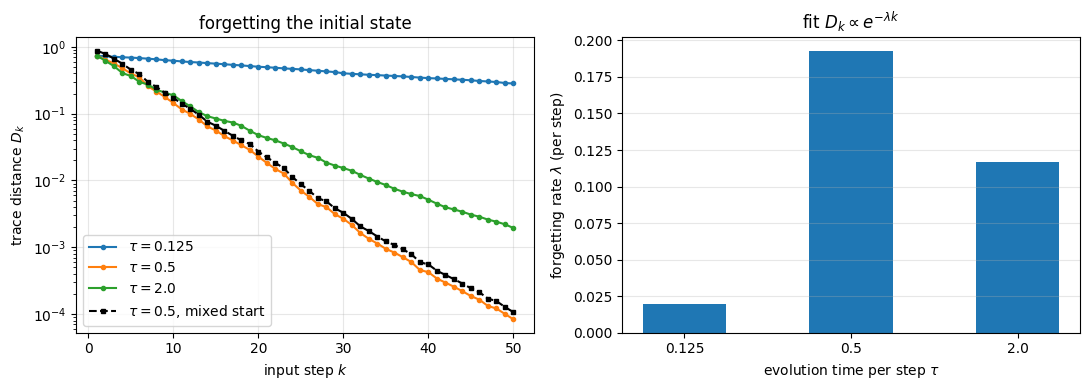

tau = 0.125:  D_1 = 0.7373, D_10 = 6.212e-01, D_50 = 2.831e-01, rate lambda = 0.020 per step  (memory time 1/lambda = 50.68 steps)
tau = 0.500:  D_1 = 0.7373, D_10 = 1.443e-01, D_50 = 8.352e-05, rate lambda = 0.192 per step  (memory time 1/lambda = 5.20 steps)
tau = 2.000:  D_1 = 0.7373, D_10 = 1.879e-01, D_50 = 1.945e-03, rate lambda = 0.117 per step  (memory time 1/lambda = 8.58 steps)
maximally mixed start, tau = 0.5: D_1 = 0.8750, D_50 = 1.067e-04

monotone decrease (no step increases D)? True


In [11]:
# ==============================================================================
# ECHO-STATE PROPERTY: two initial states, one input sequence, trace distance
# ==============================================================================
def make_echo_driver(L, R, tau, dt, order=2):
    """Drive TWO density tensors with the same input and record D_k = (1/2)||rho - rho'||_1."""
    n_sub = max(1, int(round(tau / dt)))

    def run(Js, hs, windows, rho_a, rho_b):
        gates = tebd_gates(hamiltonian_terms(Js, hs, L, R), tau / n_sub, order)

        def evolve(rho):
            return lax.scan(lambda r, _: (apply_gates_dm(r, gates), None), rho, None, length=n_sub)[0]

        def step(carry, u_window):
            ra, rb = carry
            ra = evolve(reset_and_encode_dm(ra, u_window, L))
            rb = evolve(reset_and_encode_dm(rb, u_window, L))
            return (ra, rb), trace_distance(dm_matrix(ra), dm_matrix(rb))

        return lax.scan(step, (rho_a, rho_b), windows)[1]

    return jax.jit(run)


u_echo = np.random.default_rng(3).uniform(0.0, 1.0, 50)
W_echo = input_windows(u_echo, L_IN)
rho_a0 = to_dm(zero_state(N_QUBITS))                                  # |0...0>
rho_b0 = to_dm(haar_state(jax.random.PRNGKey(11), N_QUBITS))          # a random pure state
rho_c0 = jnp.eye(2 ** N_QUBITS, dtype=CDTYPE).reshape((2,) * (2 * N_QUBITS)) / 2 ** N_QUBITS  # maximally mixed

taus_echo = (0.125, 0.5, 2.0)
D_curves = {}
for tau_e in taus_echo:
    drv_e = make_echo_driver(L_IN, N_RAILS, tau_e, DT)
    D_curves[tau_e] = np.asarray(drv_e(Js_demo, hs_demo, W_echo, rho_a0, rho_b0))
D_mixed = np.asarray(make_echo_driver(L_IN, N_RAILS, TAU, DT)(Js_demo, hs_demo, W_echo, rho_a0, rho_c0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for tau_e in taus_echo:
    D = D_curves[tau_e]
    ax[0].semilogy(np.arange(1, len(D) + 1), np.maximum(D, 1e-17), "o-", ms=3,
                   label=rf"$\tau={tau_e}$")
ax[0].semilogy(np.arange(1, len(D_mixed) + 1), np.maximum(D_mixed, 1e-17), "s--", ms=3, color="k",
               label=rf"$\tau={TAU}$, mixed start")
ax[0].set_xlabel("input step $k$"); ax[0].set_ylabel(r"trace distance $D_k$")
ax[0].set_title("forgetting the initial state"); ax[0].legend(); ax[0].grid(alpha=0.3)

rates = {}
for tau_e in taus_echo:
    D = np.maximum(D_curves[tau_e], 1e-16)
    sel = (np.arange(len(D)) >= 2) & (D > 1e-12)
    rates[tau_e] = -np.polyfit(np.arange(len(D))[sel], np.log(D[sel]), 1)[0]
ax[1].bar([str(t) for t in taus_echo], [rates[t] for t in taus_echo], color="tab:blue", width=0.5)
ax[1].set_xlabel(r"evolution time per step $\tau$"); ax[1].set_ylabel(r"forgetting rate $\lambda$ (per step)")
ax[1].set_title(r"fit $D_k \propto e^{-\lambda k}$"); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

for tau_e in taus_echo:
    D = D_curves[tau_e]
    print(f"tau = {tau_e:5.3f}:  D_1 = {D[0]:.4f}, D_10 = {D[9]:.3e}, D_50 = {D[-1]:.3e}, "
          f"rate lambda = {rates[tau_e]:.3f} per step  (memory time 1/lambda = {1/rates[tau_e]:.2f} steps)")
print(f"maximally mixed start, tau = {TAU}: D_1 = {D_mixed[0]:.4f}, D_50 = {D_mixed[-1]:.3e}")
print(f"\nmonotone decrease (no step increases D)? "
      f"{all(bool(np.all(np.diff(D_curves[t]) <= 1e-12)) for t in taus_echo)}")

Every curve decays, and no step ever increases $D_k$, as a trace-preserving positive map guarantees. Three features of
the measurement:

* **The first step is the same for all three $\tau$**: $D_1=0.737$ everywhere. The unitary part leaves the trace distance
  invariant, so the only thing that acts on $D$ in one step is the erasure — and the erasure does not know $\tau$.
* **The rate is not monotonic in $\tau$.** The fitted $\lambda$ is $0.020$ at $\tau=0.125$, $0.192$ at $\tau=0.5$ and
  $0.117$ at $\tau=2$. Slow evolution barely moves the memory-rail information into the input qubit, so little of it is
  erased and the machine remembers its initial state for tens of steps. Why the longest evolution forgets more slowly than
  the intermediate one is not settled by three values of $\tau$; a plausible reading is that what matters is how much of
  the difference $\rho_k-\rho_k'$ sits on qubit $0$ at the moment of the erasure, which need not grow with $\tau$.
* Starting from the maximally mixed state instead of a random pure state gives $D_1=0.875$ exactly. After the first
  erasure the two memory registers are $\vert000\rangle$ and $\mathbb{1}/8$, whose trace distance is $1-1/8=7/8$; the random
  pure start retains more overlap with $\vert0\dots0\rangle$ on the memory rails. The decay rate is the same as for the
  pure start ($D_{50}\approx10^{-4}$ in both cases).

One practical consequence: at $\tau=0.125$ the initial state is far from forgotten after the washout of $100$ steps used
below ($D_{50}=0.28$ and $e^{-100\lambda}\approx0.14$). This does no harm to the regression because every run starts from
the same state $\vert0\dots0\rangle$, so the residual dependence is the same deterministic transient for training,
validation and test; Exercise 2 measures it.

This is the *first* half of the trade-off of Section 2.3: slow forgetting means long memory. The second half — that a
reservoir which forgets too slowly has not mixed the input into its features either — is what the memory capacity of the
next section measures.

## 6. Memory capacity

We now drive the reservoir with an i.i.d. sequence $u_k\sim\mathcal{U}[0,1]$, the situation in which Jaeger's bound
$\mathrm{MC}\le p$ holds, and measure $C(\tau)$ of Eq. (5) for $\tau=1,\dots,60$ with the protocol of Section 2.5: washout,
contiguous train/validation/test blocks, $\alpha$ chosen on the validation block, $C(\tau)$ evaluated on the test block.
The sum runs to $60$ delays because a slowly forgetting reservoir keeps a faint but real memory beyond twenty steps
(Section 5 measured a memory time of fifty steps at $\tau=0.125$); the price is the upward bias of Section 2.6, about
$60/219\approx0.27$ for our test block of $220$ points, which the null control below measures directly.
Every number is a median over `N_RES` random reservoirs, with the full spread shown as a band. Three further error
estimates are in the first cell: the same reservoirs driven by fresh input sequences (statistical error of one MC value),
the null control (independent target), and a five times longer series (the downward bias from the finite training
block).

In [12]:
# ==============================================================================
# EXPERIMENT: memory capacity C(tau) = r^2 for the delay task, on the TEST block
# ==============================================================================
TAUS_MC = np.arange(1, 61)


def memory_capacity(F, u, taus=TAUS_MC, washout=WASHOUT):
    """C(tau) for every delay; features at step k, target u_{k-tau}.  Returns an array of r^2."""
    caps = []
    for tau in taus:
        _, r2, _, _, _ = evaluate(F[tau:], u[:len(u) - tau], washout=washout)
        caps.append(r2)
    return np.array(caps)


def drive_ensemble(L, R, tau, dt, u, V=1, n_res=N_RES, seed=SEED_RES, W=W_DIS, jump=None, gamma=0.0):
    """Drive `n_res` independent random reservoirs with the same input (vmap over disorder).

    Returns (features[n_res, T, p], (compile time, run time)).
    JAX  ahead-of-time compilation, `vdrv.lower(*args).compile()`, separates the one-off XLA
         compilation from the execution, so the two can be timed separately.
    """
    keys = jax.random.split(jax.random.PRNGKey(seed), n_res)
    Js_b, hs_b = jax.vmap(lambda k: reservoir_params(k, L, R, W=W))(keys)
    drv = make_dm_driver(L, R, tau, dt, V=V, jump=jump, gamma=gamma)
    vdrv = jax.jit(jax.vmap(drv, in_axes=(0, 0, None, None)))
    args = (Js_b, hs_b, input_windows(u, L), to_dm(zero_state(L * R)))
    t0 = time.time()
    compiled = vdrv.lower(*args).compile()
    t_compile = time.time() - t0
    t0 = time.time()
    _, F = compiled(*args)
    F = np.asarray(jax.block_until_ready(F))
    return F, (t_compile, time.time() - t0)


rng_u = np.random.default_rng(2)
u_iid = rng_u.uniform(0.0, 1.0, T_LEN)                 # the i.i.d. drive used in Sections 6, 7, 9, 10

F_iid, (tc_drive, t_drive) = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid)
print(f"{N_RES} reservoirs x {T_LEN} steps x {F_iid.shape[2]} features: compilation {tc_drive:.1f} s, "
      f"run {t_drive:.2f} s ({1e3*t_drive/(N_RES*T_LEN):.3f} ms per reservoir and step)")
caps_all = np.array([memory_capacity(F_iid[i], u_iid) for i in range(N_RES)])
MC_all = caps_all.sum(axis=1)

# (1) statistical error of ONE MC value: the same six reservoirs, two fresh i.i.d. input sequences
MC_seeds = [MC_all]
for s_in in (31, 32):
    u_alt = np.random.default_rng(s_in).uniform(0.0, 1.0, T_LEN)
    F_alt, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_alt)
    MC_seeds.append(np.array([memory_capacity(F_alt[i], u_alt).sum() for i in range(N_RES)]))
MC_seeds = np.array(MC_seeds)                                  # (3 input sequences, N_RES reservoirs)
sd_input = float(np.sqrt(np.mean(MC_seeds.var(axis=0, ddof=1))))   # pooled over reservoirs
print(f"MC of each reservoir for three input sequences:\n{np.array2string(MC_seeds, precision=3)}")
print(f"pooled standard deviation over input sequences: {sd_input:.3f}  "
      f"(reservoir-to-reservoir spread of the first row: {MC_all.std(ddof=1):.3f})")

# (2) null control: the same features, but the target is an INDEPENDENT random sequence
u_null = np.random.default_rng(4321).uniform(0.0, 1.0, T_LEN)
MC_null = np.array([memory_capacity(F_iid[i], u_null).sum() for i in range(N_RES)])
print(f"null control MC (no memory possible): {np.array2string(MC_null, precision=3)}, mean {MC_null.mean():.3f} "
      f"+- {MC_null.std(ddof=1)/np.sqrt(N_RES):.3f};  prediction sum_tau 1/(n_te-1) = "
      f"{sum(1.0 / (split_indices(T_LEN - t, WASHOUT)[2].stop - split_indices(T_LEN - t, WASHOUT)[2].start - 1) for t in TAUS_MC):.3f}")

# (3) the downward bias from the finite training block: a five times longer series
T_LONG = 5 * T_LEN
u_long = np.random.default_rng(33).uniform(0.0, 1.0, T_LONG)
F_long, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_long)
MC_long = np.array([memory_capacity(F_long[i], u_long).sum() for i in range(N_RES)])
MC_long_null = np.array([memory_capacity(F_long[i], np.random.default_rng(4322).uniform(0.0, 1.0, T_LONG)).sum()
                         for i in range(N_RES)])
print(f"T = {T_LONG}: MC {np.array2string(MC_long, precision=3)}, median {np.median(MC_long):.3f};  "
      f"null control mean {MC_long_null.mean():.3f}")
print(f"MC(T={T_LONG}) - MC(T={T_LEN}) per reservoir: {np.array2string(MC_long - MC_all, precision=3)}, "
      f"mean {np.mean(MC_long - MC_all):+.3f} +- {np.std(MC_long - MC_all, ddof=1) / np.sqrt(N_RES):.3f}\n")
assert MC_null.mean() < 0.5 and np.median(MC_all) > 5 * MC_null.mean()

# Does the Trotter step matter for the SCORE (not for the state)?  Re-drive with dt/4.
F_fine, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT / 4, u_iid)
MC_fine = np.array([memory_capacity(F_fine[i], u_iid).sum() for i in range(N_RES)])
print(f"Trotter check: MC with dt = {DT} : {np.array2string(MC_all, precision=3)}")
print(f"               MC with dt = {DT/4}: {np.array2string(MC_fine, precision=3)}")
print(f"               largest change {np.abs(MC_all - MC_fine).max():.4f}, "
      f"reservoir-to-reservoir spread {MC_all.max() - MC_all.min():.4f}\n")

print(f"median MC = {np.median(MC_all):.3f},  number of features p = {F_iid.shape[2]}  ->  Jaeger bound MC <= p")

# how many of the p features are linearly independent?
Xs = (F_iid[0][WASHOUT:] - F_iid[0][WASHOUT:].mean(0)) / np.maximum(F_iid[0][WASHOUT:].std(0), 1e-12)
sv = np.linalg.svd(Xs, compute_uv=False)
eff_rank = float(np.sum(sv) ** 2 / np.sum(sv ** 2))
print(f"singular values of the standardised feature matrix (reservoir 0): "
      f"{np.array2string(sv[:6]/sv[0], precision=3)} ... {sv[-1]/sv[0]:.2e}")
print(f"effective rank (sum sigma)^2 / sum sigma^2 = {eff_rank:.2f} of {F_iid.shape[2]} columns;  "
      f"participation ratio of the eigenvalues sigma^2 of X^T X: {np.sum(sv**2)**2/np.sum(sv**4):.2f}")

6 reservoirs x 1200 steps x 21 features: compilation 0.4 s, run 0.99 s (0.137 ms per reservoir and step)


MC of each reservoir for three input sequences:
[[3.598 3.696 3.098 3.939 4.499 4.098]
 [4.01  5.025 3.764 4.282 5.582 4.625]
 [3.831 4.308 3.448 4.172 4.21  4.125]]
pooled standard deviation over input sequences: 0.454  (reservoir-to-reservoir spread of the first row: 0.477)


null control MC (no memory possible): [0.255 0.276 0.258 0.434 0.276 0.346], mean 0.307 +- 0.029;  prediction sum_tau 1/(n_te-1) = 0.281


T = 6000: MC [3.875 4.43  3.377 4.068 4.668 4.318], median 4.193;  null control mean 0.035
MC(T=6000) - MC(T=1200) per reservoir: [0.277 0.734 0.279 0.129 0.169 0.22 ], mean +0.301 +- 0.090



Trotter check: MC with dt = 0.125 : [3.598 3.696 3.098 3.939 4.499 4.098]
               MC with dt = 0.03125: [3.598 3.806 3.062 3.94  4.475 4.074]
               largest change 0.1105, reservoir-to-reservoir spread 1.4003

median MC = 3.817,  number of features p = 21  ->  Jaeger bound MC <= p
singular values of the standardised feature matrix (reservoir 0): [1.    0.849 0.763 0.738 0.598 0.558] ... 6.76e-02
effective rank (sum sigma)^2 / sum sigma^2 = 14.50 of 21 columns;  participation ratio of the eigenvalues sigma^2 of X^T X: 8.84


tau sweep: 5 ensembles, compilation 2.2 s, run 7.3 s


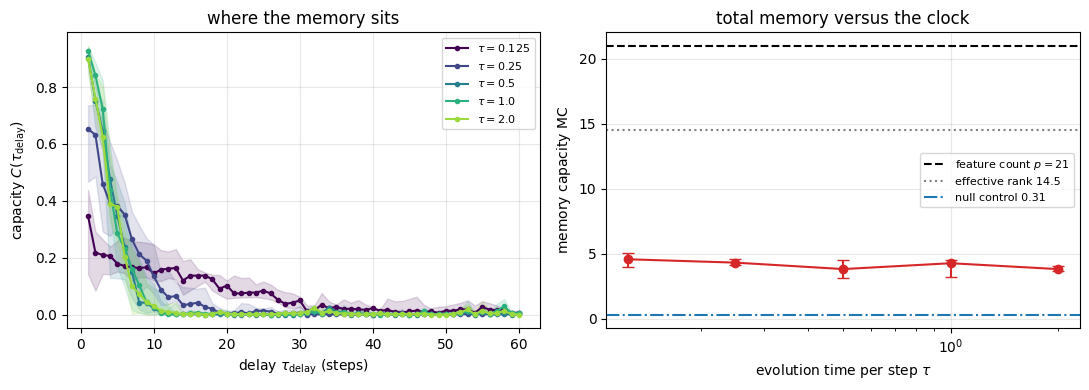

 tau    MC_1..60 (median)  [min, max] over reservoirs   MC_1..20   C(1)    C(5)    C(20)   C(40)
 0.125       4.571       [3.996, 5.084]            3.257   0.346   0.180   0.102   0.022
 0.250       4.313       [4.103, 4.617]            4.129   0.652   0.383   0.002   0.001
 0.500       3.817       [3.098, 4.499]            3.633   0.905   0.348   0.002   0.001
 1.000       4.267       [3.201, 4.488]            4.017   0.928   0.286   0.002   0.002
 2.000       3.813       [3.664, 4.053]            3.576   0.899   0.380   0.003   0.001
(null control per delay: 0.0051)


In [13]:
# ==============================================================================
# EXPERIMENT: C(tau) profile, and MC against the evolution time tau
# ==============================================================================
TAU_SWEEP = (0.125, 0.25, 0.5, 1.0, 2.0)
caps_by_tau, F_by_tau, t_c, t_r = {}, {}, 0.0, 0.0
for tau_s in TAU_SWEEP:
    F_by_tau[tau_s], (tc_s, tr_s) = drive_ensemble(L_IN, N_RAILS, tau_s, DT, u_iid)   # kept for Section 7
    caps_by_tau[tau_s] = np.array([memory_capacity(F_by_tau[tau_s][i], u_iid) for i in range(N_RES)])
    t_c, t_r = t_c + tc_s, t_r + tr_s
print(f"tau sweep: {len(TAU_SWEEP)} ensembles, compilation {t_c:.1f} s, run {t_r:.1f} s")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(TAU_SWEEP)))
for c, tau_s in zip(colors, TAU_SWEEP):
    C = caps_by_tau[tau_s]
    ax[0].plot(TAUS_MC, np.median(C, axis=0), "o-", ms=3, color=c, label=rf"$\tau={tau_s}$")
    ax[0].fill_between(TAUS_MC, C.min(axis=0), C.max(axis=0), color=c, alpha=0.15)
ax[0].set_xlabel(r"delay $\tau_{\rm delay}$ (steps)"); ax[0].set_ylabel(r"capacity $C(\tau_{\rm delay})$")
ax[0].set_title("where the memory sits"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

mc_med = [np.median(caps_by_tau[t].sum(axis=1)) for t in TAU_SWEEP]
mc_lo = [caps_by_tau[t].sum(axis=1).min() for t in TAU_SWEEP]
mc_hi = [caps_by_tau[t].sum(axis=1).max() for t in TAU_SWEEP]
ax[1].errorbar(TAU_SWEEP, mc_med, yerr=[np.array(mc_med) - mc_lo, np.array(mc_hi) - np.array(mc_med)],
               fmt="o-", capsize=4, color="tab:red")
ax[1].axhline(F_iid.shape[2], ls="--", color="k", label=rf"feature count $p={F_iid.shape[2]}$")
ax[1].axhline(eff_rank, ls=":", color="gray", label=f"effective rank {eff_rank:.1f}")
ax[1].axhline(MC_null.mean(), ls="-.", color="tab:blue", label=f"null control {MC_null.mean():.2f}")
ax[1].set_xscale("log"); ax[1].set_xlabel(r"evolution time per step $\tau$")
ax[1].set_ylabel(r"memory capacity $\mathrm{MC}$")
ax[1].set_title("total memory versus the clock"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(" tau    MC_1..60 (median)  [min, max] over reservoirs   MC_1..20   C(1)    C(5)    C(20)   C(40)")
for tau_s in TAU_SWEEP:
    C = caps_by_tau[tau_s]
    m = C.sum(axis=1)
    print(f"{tau_s:6.3f}    {np.median(m):8.3f}       [{m.min():.3f}, {m.max():.3f}]           "
          f"{np.median(C[:, :20].sum(1)):6.3f}   {np.median(C[:, 0]):.3f}   {np.median(C[:, 4]):.3f}   "
          f"{np.median(C[:, 19]):.3f}   {np.median(C[:, 39]):.3f}")
print(f"(null control per delay: {MC_null.mean()/len(TAUS_MC):.4f})")

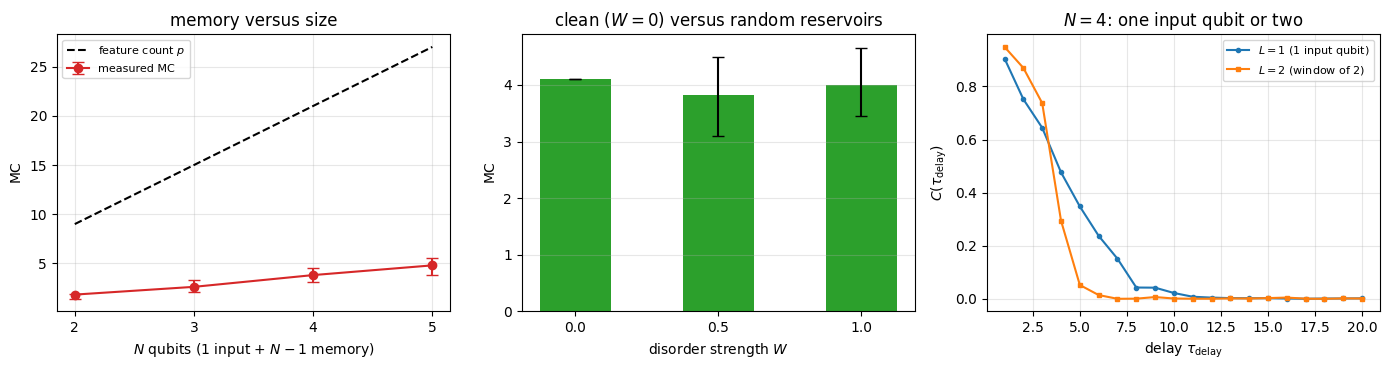

N   p    MC median   [min, max]
2    9     1.834    [1.405, 1.917]
3   15     2.623    [2.067, 3.348]
4   21     3.817    [3.098, 4.499]
5   27     4.805    [3.874, 5.523]

W      MC median
 0.0     4.098    [4.098, 4.098]
 0.5     3.817    [3.098, 4.499]
 1.0     4.002    [3.451, 4.662]

L=1, N=4: MC = 3.817, C(1) = 0.905, C(2) = 0.752, p = 21
L=2, N=4: MC = 3.224, C(1) = 0.949, C(2) = 0.870, p = 24


In [14]:
# ==============================================================================
# EXPERIMENT: MC against the number of qubits, the disorder, the input-rail length
# ==============================================================================
N_SWEEP = (2, 3, 4, 5)
mc_vs_N, p_vs_N = {}, {}
for R_s in N_SWEEP:
    F_s, _ = drive_ensemble(1, R_s, TAU, DT, u_iid)
    mc_vs_N[R_s] = np.array([memory_capacity(F_s[i], u_iid).sum() for i in range(N_RES)])
    p_vs_N[R_s] = F_s.shape[2]

mc_vs_W = {}
for W_s in (0.0, 0.5, 1.0):
    F_s, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, W=W_s)
    mc_vs_W[W_s] = np.array([memory_capacity(F_s[i], u_iid).sum() for i in range(N_RES)])

F_L2, _ = drive_ensemble(2, 2, TAU, DT, u_iid)          # the 2 x 2 plaquette: two input qubits
caps_L2 = np.array([memory_capacity(F_L2[i], u_iid) for i in range(N_RES)])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].errorbar(N_SWEEP, [np.median(mc_vs_N[n]) for n in N_SWEEP],
               yerr=[[np.median(mc_vs_N[n]) - mc_vs_N[n].min() for n in N_SWEEP],
                     [mc_vs_N[n].max() - np.median(mc_vs_N[n]) for n in N_SWEEP]],
               fmt="o-", capsize=4, color="tab:red", label="measured MC")
ax[0].plot(N_SWEEP, [p_vs_N[n] for n in N_SWEEP], "k--", label="feature count $p$")
ax[0].set_xlabel("$N$ qubits ($1$ input $+$ $N-1$ memory)"); ax[0].set_ylabel(r"$\mathrm{MC}$")
ax[0].set_xticks(N_SWEEP); ax[0].set_title("memory versus size"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].bar([f"{w}" for w in mc_vs_W], [np.median(v) for v in mc_vs_W.values()],
          yerr=[[np.median(v) - v.min() for v in mc_vs_W.values()],
                [v.max() - np.median(v) for v in mc_vs_W.values()]],
          capsize=4, color="tab:green", width=0.5)
ax[1].set_xlabel("disorder strength $W$"); ax[1].set_ylabel(r"$\mathrm{MC}$")
ax[1].set_title(r"clean ($W=0$) versus random reservoirs"); ax[1].grid(alpha=0.3, axis="y")

ax[2].plot(TAUS_MC[:20], np.median(caps_all, axis=0)[:20], "o-", ms=3, label=r"$L=1$ (1 input qubit)")
ax[2].plot(TAUS_MC[:20], np.median(caps_L2, axis=0)[:20], "s-", ms=3, label=r"$L=2$ (window of 2)")
ax[2].set_xlabel(r"delay $\tau_{\rm delay}$"); ax[2].set_ylabel(r"$C(\tau_{\rm delay})$")
ax[2].set_title(r"$N=4$: one input qubit or two"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("N   p    MC median   [min, max]")
for n in N_SWEEP:
    print(f"{n}  {p_vs_N[n]:3d}   {np.median(mc_vs_N[n]):7.3f}    [{mc_vs_N[n].min():.3f}, {mc_vs_N[n].max():.3f}]")
print("\nW      MC median")
for w, v in mc_vs_W.items():
    print(f"{w:4.1f}   {np.median(v):7.3f}    [{v.min():.3f}, {v.max():.3f}]")
print(f"\nL=1, N=4: MC = {np.median(caps_all.sum(1)):.3f}, C(1) = {np.median(caps_all[:,0]):.3f}, "
      f"C(2) = {np.median(caps_all[:,1]):.3f}, p = {F_iid.shape[2]}")
print(f"L=2, N=4: MC = {np.median(caps_L2.sum(1)):.3f}, C(1) = {np.median(caps_L2[:,0]):.3f}, "
      f"C(2) = {np.median(caps_L2[:,1]):.3f}, p = {F_L2.shape[2]}")

In [15]:
# ==============================================================================
# EXPERIMENT: temporal multiplexing -- V readouts inside one interval tau
# ==============================================================================
V_SWEEP = (1, 2, 4)
F_by_V, caps_by_V = {}, {}
for V_s in V_SWEEP:
    F_by_V[V_s], dt_s = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, V=V_s)
    caps_by_V[V_s] = np.array([memory_capacity(F_by_V[V_s][i], u_iid) for i in range(N_RES)])
    print(f"V = {V_s}: p = {F_by_V[V_s].shape[2]:3d} features, "
          f"MC = {np.median(caps_by_V[V_s].sum(1)):.3f} "
          f"[{caps_by_V[V_s].sum(1).min():.3f}, {caps_by_V[V_s].sum(1).max():.3f}]  "
          f"(compilation {dt_s[0]:.1f} s, run {dt_s[1]:.1f} s)")

V = 1: p =  21 features, MC = 3.817 [3.098, 4.499]  (compilation 0.5 s, run 1.0 s)


V = 2: p =  42 features, MC = 4.270 [3.438, 4.826]  (compilation 0.6 s, run 1.0 s)


V = 4: p =  84 features, MC = 4.614 [3.865, 5.307]  (compilation 1.0 s, run 1.1 s)


### 6.1 What the memory measurements say

* **How precise is one number.** Driving the same six reservoirs with two fresh input sequences moves each MC by a pooled
  standard deviation of $0.45$ — as large as the reservoir-to-reservoir spread ($0.48$). With $220$ test points a single
  MC value is uncertain by about $\pm0.45$, so differences between individual reservoirs, and differences of a few tenths
  between the medians below, are not resolved. The null control scores $\mathrm{MC}=0.31\pm0.03$ with no memory at all,
  in agreement with the prediction $\sum_\tau1/(n_{\rm te}-1)=0.28$ of Section 2.6, and the five times longer series raises
  the capacity of every reservoir, by $0.30\pm0.09$ on average, while its own null control falls to $0.035$. At $T=1200$
  the two biases have opposite sign and similar size; the medians quoted below are therefore close to the long-series
  values ($3.82$ against $4.19$), but only by this coincidence.
* **The capacity profile moves with $\tau$, the total much less.** $C(\tau_{\rm delay})$ starts near $1$ and decays over a
  few steps for $\tau\ge0.5$ ($C(1)\approx0.9$, nothing above the null level after about ten steps). At $\tau=0.125$ the
  first delay is poorly resolved ($C(1)=0.35$) but a faint tail survives far beyond twenty steps ($C(20)=0.10$,
  $C(40)=0.02$, against $0.005$ per delay for the null control) — the slow forgetting of Section 5 seen from the readout.
  Summed to $60$ delays this tail makes $\tau=0.125$ the machine with the *largest* total ($4.57$, against $3.8$–$4.3$ for
  the other four values); truncated at twenty delays it would have appeared as the smallest ($3.26$). The other four totals
  differ by at most $0.5$, about the uncertainty of one MC value. The *total* linear memory is not conserved — Dambre's sum rule
  fixes the sum over *all* orthogonal functionals, linear and nonlinear, not the linear part — but over a sixteenfold
  range of $\tau$ it changes far less than the profile does.
* **The bound is satisfied with room to spare**: $\mathrm{MC}=3.82$ against $p=21$ features. Part of the gap is
  redundancy — the singular values of the standardised feature matrix span a factor of $15$, the effective rank
  $(\sum_i\sigma_i)^2/\sum_i\sigma_i^2$ is $14.5$, and the participation ratio of the eigenvalues $\sigma_i^2$ of
  $X^{\rm T}X$ is only $8.8$ — but even against these numbers the measured capacity is small. The rest of the gap is that the
  bound is saturated only by a *complete* set of target functionals; the delay task probes the linear ones only, and the
  remaining capacity sits in nonlinear functionals.
* **Size helps, roughly linearly**: $1.83,\,2.62,\,3.82,\,4.81$ for $N=2,3,4,5$, i.e. about one extra delay remembered
  per added memory qubit, while the feature count grows by six per qubit. The $4^N$-dimensional state space is not
  converted into $4^N$ usable memory slots by a readout of one- and two-body observables.
* **Disorder hardly changes the capacity.** The clean lattice ($W=0$) reaches $\mathrm{MC}=4.10$, inside the spread of the
  disordered ensembles ($3.82$ at $W=0.5$, $4.00$ at $W=1$). (All six $W=0$ "draws" are the same Hamiltonian, which is
  why that bar has no error bar at all: a useful check that the spread really comes from the disorder.) What disorder
  buys is the possibility of *statistics*: a family of machines rather than one.
* **Where to put the input.** With $L=2$ the two most recent inputs are written into the register at every step, so
  $C(1)=0.95$ and $C(2)=0.87$ are high for a trivial reason — they are read off the input rail, not recalled. But only
  two qubits are left to remember anything, the profile collapses after a few delays, and the total ($\mathrm{MC}=3.22$
  with $p=24$) is below the single-input-qubit machine ($3.82$ with $p=21$), by a margin comparable with the uncertainty.
* **Multiplexing** raises the capacity at fixed hardware — $3.82\to4.27\to4.61$ for $V=1,2,4$ — and by far less than the
  factor $V$ by which the feature count grows. The $V$ snapshots inside one interval are strongly correlated with each
  other, which is the same redundancy that the effective rank already exposed.

## 7. NARMA: memory *and* nonlinearity

The delay task is linear in the input, so a reservoir could score well on it with no nonlinearity at all. NARMA is the
standard cure: Eqs. (6) and (7) define a target that depends on products of past inputs and on its own past. We drive with
the same i.i.d. sequence as in Section 6, rescaled to the interval $[0,0.5]$ that the NARMA literature uses, and train the
same ridge readout. Every baseline is trained on the same blocks with the same $\alpha$ grid and has $p=21$ features:

* $\mathrm{AR}(p)$, a linear autoregression on the last $p$ inputs (no nonlinearity at all);
* $\mathrm{AR}^2(p)$, the last $11$ inputs and the squares of the last $10$ (a static polynomial, no dynamics);
* $\mathrm{ESN}(p)$, a classical echo-state network with $p$ units, once with the default scalings (spectral radius $0.9$
  of $W$, input weights $w_{\rm in}$ uniform in $[-s,s]$ with input scale $s=1$) and once with both chosen on the validation block from a $3\times4$ grid;
* as a reference without a feature budget, $\mathrm{ESN}(200)$ with default scalings.

A comparison in which the model under test has its knobs set by hand while the baseline runs at default settings, or the
reverse, says little; so the quantum reservoir also gets its one cheap knob tuned: the evolution time $\tau$ is chosen on
the validation block from the five values of the sweep in Section 6. A further row isolates the encoding: ridge regression
on $\cos\pi u$ and $\sin\pi u$ of the last $10$ inputs ($20$ features), i.e. the function space of Eq. (14) for single
inputs with a perfect memory of ten steps and no cross-time products.

In [16]:
# ==============================================================================
# EXPERIMENT: NARMA-2, NARMA-5, NARMA-10 -- quantum reservoir versus baselines
# ==============================================================================
u_narma = 0.5 * u_iid                       # the drive encoded in the qubit is u_iid; NARMA sees u_iid/2
targets = {"NARMA-2": narma2(u_narma), "NARMA-5": narma_n(u_narma, 5), "NARMA-10": narma_n(u_narma, 10)}
p_feat = F_iid.shape[2]


def score_val(F, y):
    """(test NMSE, validation NMSE) of the ridge readout -- the input of `select_on_validation`."""
    out = evaluate(F, y, return_val=True)
    return out[0], out[-1]


# echo-state networks: features for every grid point and seed, computed once and reused for all targets
esn_cands = {cfg: [esn_features(u_iid, p_feat, seed=s, rho_sr=cfg[0], scale_in=cfg[1]) for s in range(N_RES)]
             for cfg in ESN_GRID}
trig_lags = np.hstack([ar_features(np.cos(np.pi * u_iid), 10), ar_features(np.sin(np.pi * u_iid), 10)])

rows, chosen = [], {}
for name, y in targets.items():
    q = np.array([evaluate(F_iid[i], y)[0] for i in range(N_RES)])
    q4 = np.array([evaluate(F_by_V[4][i], y)[0] for i in range(N_RES)])
    tau_best, q_tau = select_on_validation({t: list(F_by_tau[t]) for t in TAU_SWEEP}, lambda F: score_val(F, y))
    ar = evaluate(ar_features(u_iid, p_feat), y)[0]
    ar2 = evaluate(ar2_features(u_iid, p_feat), y)[0]
    esn = np.array([evaluate(F, y)[0] for F in esn_cands[(0.9, 1.0)]])
    cfg_best, esn_t = select_on_validation(esn_cands, lambda F: score_val(F, y))
    esn_big = np.array([evaluate(esn_features(u_iid, 200, seed=s), y)[0] for s in range(N_RES)])
    trig = evaluate(trig_lags, y)[0]
    chosen[name] = (tau_best, cfg_best)
    rows.append((name, q, q4, q_tau, ar, ar2, esn, esn_t, esn_big, trig))

# how linear are the two nonlinearities involved?
print(f"correlation of the NARMA input nonlinearity with the input itself: "
      f"corr(u, u^3) = {np.corrcoef(u_narma, u_narma**3)[0, 1]:.4f} on [0, 0.5]")
print(f"test NMSE, median over {N_RES} reservoirs / seeds [min, max]; p = {p_feat} features unless stated\n")
cols = ("QRC tau=0.5", "QRC V=4 (84)", "QRC tau tuned", "AR(p)", "AR^2(p)", "ESN(p) default", "ESN(p) tuned",
        "ESN(200)", "cos/sin lags (20)")
for name, *vals in rows:
    print(f"{name}  (tau chosen on validation: {chosen[name][0]}; ESN (radius, input scale) chosen: {chosen[name][1]})")
    for c, v in zip(cols, vals):
        v = np.atleast_1d(v)
        print(f"   {c:18s} {np.median(v):7.4f}" + (f"   [{v.min():.3f}, {v.max():.3f}]" if len(v) > 1 else ""))

correlation of the NARMA input nonlinearity with the input itself: corr(u, u^3) = 0.9206 on [0, 0.5]
test NMSE, median over 6 reservoirs / seeds [min, max]; p = 21 features unless stated

NARMA-2  (tau chosen on validation: 1.0; ESN (radius, input scale) chosen: (0.5, 0.1))
   QRC tau=0.5         0.3198   [0.282, 0.468]
   QRC V=4 (84)        0.2226   [0.185, 0.287]
   QRC tau tuned       0.2109   [0.170, 0.295]
   AR(p)               0.1524
   AR^2(p)             0.0053
   ESN(p) default      0.1474   [0.070, 0.193]
   ESN(p) tuned        0.0259   [0.013, 0.046]
   ESN(200)            0.0186   [0.013, 0.022]
   cos/sin lags (20)   0.0338
NARMA-5  (tau chosen on validation: 2.0; ESN (radius, input scale) chosen: (0.9, 0.1))
   QRC tau=0.5         0.6176   [0.572, 0.708]
   QRC V=4 (84)        0.4838   [0.459, 0.595]
   QRC tau tuned       0.4888   [0.373, 0.692]
   AR(p)               0.1324
   AR^2(p)             0.1346
   ESN(p) default      0.2740   [0.201, 0.347]
   ESN(p) tuned   

**The quantum reservoir is the weakest model in the table on all three tasks.** With $p=21$ features at $\tau=0.5$ it
reaches a test NMSE of $0.32$ on NARMA-2, $0.62$ on NARMA-5 and $0.78$ on NARMA-10. Choosing $\tau$ on the validation
block improves this to $0.21$, $0.49$ and $0.75$, and multiplexing to $84$ features gives $0.22$, $0.48$ and $0.75$. The
classical models with the same $21$ features do better: the linear autoregression reaches $0.15$, $0.13$, $0.19$; the
echo-state network at default scalings $0.15$, $0.27$, $0.69$, and with its two scalings chosen on the validation block
$0.026$, $0.13$, $0.28$. The quadratic autoregression solves NARMA-2 almost exactly ($0.005$).

The table also says *why*, because its rows separate the ingredients.

1. **The encoding is not the bottleneck.** Ridge regression on $\cos\pi u$ and $\sin\pi u$ of the last ten inputs — the
   single-input function space of Eq. (14), with a perfect memory of ten steps — reaches $0.034$ on NARMA-2. The
   trigonometric functions represent $u^3$ well enough (Section 4.4: $3\,\%$ of its variance is missed), so a reservoir
   whose features contained these lags accurately would be about ten times better than ours.
2. **Nonlinearity matters for NARMA-2.** The best linear model of the inputs stops at $0.15$, and adding the squares of
   the last ten inputs lowers the error thirtyfold. The $85\,\%$ of the variance of $u^3$ that $u$ explains
   ($\operatorname{corr}(u,u^3)=0.921$ on $[0,0.5]$) is not enough at this level of accuracy.
3. **What the reservoir lacks is accurate recall of the recent inputs.** NARMA-2 is dominated by $0.6\,u_{k-1}^3$, yet the
   reservoir recovers even the *linear* function $u_{k-1}$ only with $C(1)=0.905$, and $u_{k-2}$ with $C(2)=0.75$; whatever
   variance of the target is carried by the recent inputs and missing from the features is lost to every readout. The
   lag models are handed the recent inputs exactly. For NARMA-5 and NARMA-10 the required memory depth exceeds what a
   reservoir with $\mathrm{MC}\approx4$ holds, and the quadratic terms no longer help (they cost lags).

At equal feature count the two sides carry different amounts of usable information: $21$ exact input lags are $21$
linearly independent numbers, while $21$ quantum expectation values have an effective rank of $14.5$ and encode a memory
of about four steps. This redundancy is a property of the reservoir and part of the measured result. Section 10 returns to NARMA-2 with a dissipative reservoir, which raises $C(1)$ and improves the
score, though not to the level of the tuned classical baselines.

## 8. The Santa Fe laser series

Data set A of the Santa Fe time-series competition is a univariate record of the intensity of an
$81.5\,\mu\mathrm{m}$ $^{14}$NH$_3$ far-infrared laser in a chaotic regime, contributed by U. Hübner from measurements
collected primarily by N. B. Abraham and C. O. Weiss, and published with the competition proceedings edited by Weigend and
Gershenfeld. The series alternates between stretches of growing oscillations and abrupt collapses. The competition data
set is $1000$ points long, with a later continuation of $9093$ further points; the file `../data/santafe.txt` holds $4000$
samples of the series, standardised to zero mean and unit variance. The analog-to-digital conversion is still visible:
the cell below finds that the distinct values lie on a uniform lattice of $254$ levels, consistent with an $8$-bit
converter (an inference from the data, not a documented property).

4000 samples, mean +4.439e-07, std 0.999875, min -1.1859, max 4.0036
229 distinct values; smallest gap 0.02050; the values fit the lattice min + n*gap with n = 0..253 to within 3.0e-03 (the file stores 5 digits, and the gap itself is uncertain by ~1e-5, i.e. ~2.5e-03 at the top level)
encoding range from steps 0..759; the whole working series then spans [0.000, 1.000]
working series: 1200 points -> washout 100, train 660, validation 220, test 220
autocorrelation of the series at lags 1..16: [ 0.53 -0.19 -0.56 -0.61 -0.41  0.07  0.66  0.77  0.23 -0.34 -0.57 -0.5
 -0.17  0.32  0.63  0.43]
  (the i.i.d. drive of Section 6 at lag 1: -0.0105)


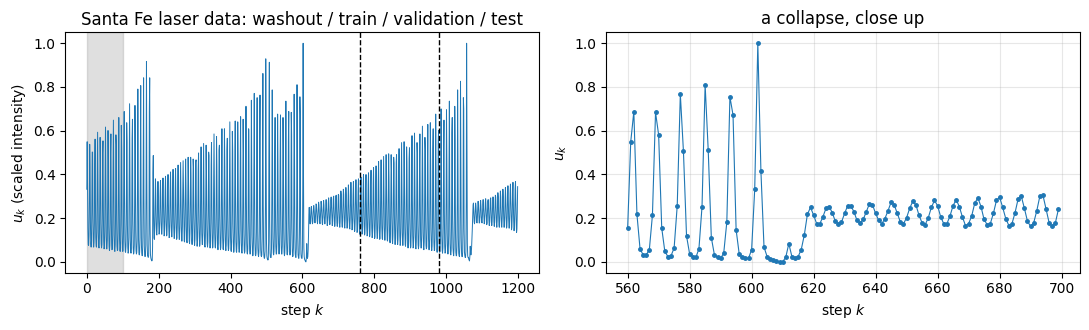

In [17]:
# ==============================================================================
# DATA: the Santa Fe laser series
# ==============================================================================
santafe_raw = np.loadtxt("../data/santafe.txt")
print(f"{len(santafe_raw)} samples, mean {santafe_raw.mean():+.3e}, std {santafe_raw.std():.6f}, "
      f"min {santafe_raw.min():.4f}, max {santafe_raw.max():.4f}")

uniq = np.unique(santafe_raw)
step = np.diff(uniq).min()
levels = np.round((santafe_raw - santafe_raw.min()) / step)
resid = np.abs(santafe_raw - (levels * step + santafe_raw.min())).max()
print(f"{len(uniq)} distinct values; smallest gap {step:.5f}; the values fit the lattice "
      f"min + n*gap with n = 0..{int(levels.max())} to within {resid:.1e} "
      f"(the file stores 5 digits, and the gap itself is uncertain by ~1e-5, i.e. ~{254e-5:.1e} at the top level)")

s_sf = santafe_raw[:T_LEN]
tr_sf, va_sf, te_sf = split_indices(T_LEN, WASHOUT)
# min-max to [0,1] for the encoding, with the min and max of the washout + TRAINING part only (no test statistics)
s_lo, s_hi = s_sf[:tr_sf.stop].min(), s_sf[:tr_sf.stop].max()
u_sf = (s_sf - s_lo) / (s_hi - s_lo)
print(f"encoding range from steps 0..{tr_sf.stop - 1}; the whole working series then spans [{u_sf.min():.3f}, {u_sf.max():.3f}]")
print(f"working series: {T_LEN} points -> washout {WASHOUT}, train {tr_sf.stop-tr_sf.start}, "
      f"validation {va_sf.stop-va_sf.start}, test {te_sf.stop-te_sf.start}")
acf = [np.corrcoef(u_sf[lag:], u_sf[:-lag])[0, 1] for lag in range(1, 17)]
print(f"autocorrelation of the series at lags 1..16: {np.array2string(np.array(acf), precision=2)}")
print(f"  (the i.i.d. drive of Section 6 at lag 1: {np.corrcoef(u_iid[1:], u_iid[:-1])[0,1]:+.4f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(np.arange(T_LEN), u_sf, lw=0.7, color="tab:blue")
for x, c in ((tr_sf.stop, "k"), (va_sf.stop, "k")):
    ax[0].axvline(x, color=c, ls="--", lw=1)
ax[0].axvspan(0, WASHOUT, color="gray", alpha=0.25)
ax[0].set_xlabel("step $k$"); ax[0].set_ylabel(r"$u_k$ (scaled intensity)")
ax[0].set_title("Santa Fe laser data: washout / train / validation / test")
ax[1].plot(np.arange(560, 700), u_sf[560:700], "o-", ms=2.5, lw=0.8, color="tab:blue")
ax[1].set_xlabel("step $k$"); ax[1].set_ylabel(r"$u_k$"); ax[1].set_title("a collapse, close up")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

two ensembles driven with the laser series: compilation 1.5 s, run 2.1 s



test NMSE of predicting u(k+h) -- median over 6 reservoirs / seeds [min, max at h=1]
model                    h=1       h=2       h=4       h=8
QRC V=1               0.0931    0.2680    0.2907    0.2543    [0.069, 0.112]
QRC V=4               0.0244    0.1684    0.1773    0.1450    [0.020, 0.045]
AR(21)                0.2602    0.3865    0.3480    0.3582
AR2(21)               0.1061    0.3192    0.3228    0.3767
ESN(21) default       0.0971    0.2952    0.3010    0.2542    [0.042, 0.161]
ESN(21) tuned         0.0420    0.2580    0.3034    0.2316    [0.035, 0.049]
ESN(200) default      0.0124    0.1270    0.1409    0.1274    [0.011, 0.033]
ESN(p) (radius, input scale) chosen on validation for h = (1, 2, 4, 8): [(0.5, 3.0), (0.5, 3.0), (0.5, 1.0), (0.5, 3.0)]


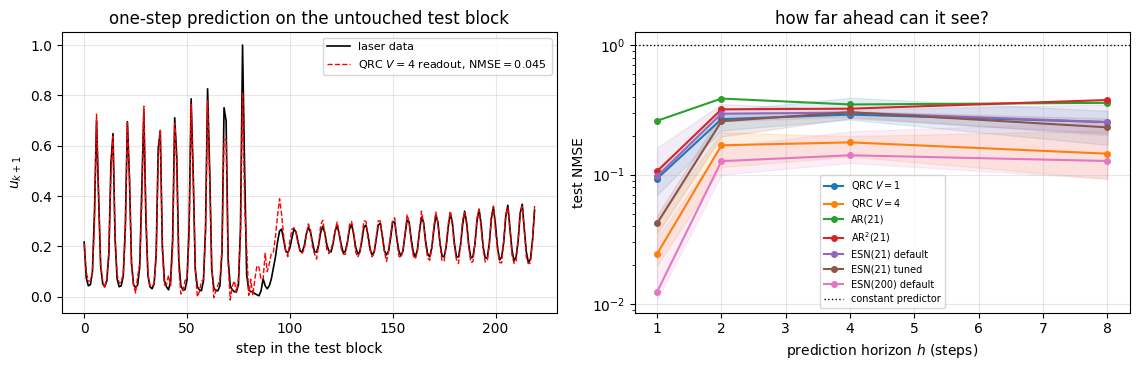


single configuration shown in the left panel: reservoir 0, V=4, h=1: NMSE 0.0453, r^2 0.9572, alpha chosen on the validation block = 0.1


In [18]:
# ==============================================================================
# EXPERIMENT: one-step and multi-step prediction of the laser series
# ==============================================================================
HORIZONS = (1, 2, 4, 8)
F_sf1, t_sf1 = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, V=1)
F_sf4, t_sf4 = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, V=4)
print(f"two ensembles driven with the laser series: compilation {t_sf1[0] + t_sf4[0]:.1f} s, "
      f"run {t_sf1[1] + t_sf4[1]:.1f} s")


def horizon_scores(F, u, h):
    """NMSE of predicting u_{k+h} from the features at step k."""
    return evaluate(F[:len(u) - h], u[h:])


res_sf = {"QRC $V=1$": np.array([[horizon_scores(F_sf1[i], u_sf, h)[0] for h in HORIZONS] for i in range(N_RES)]),
          "QRC $V=4$": np.array([[horizon_scores(F_sf4[i], u_sf, h)[0] for h in HORIZONS] for i in range(N_RES)]),
          f"AR({p_feat})": np.array([[horizon_scores(ar_features(u_sf, p_feat), u_sf, h)[0] for h in HORIZONS]]),
          f"AR$^2$({p_feat})": np.array([[horizon_scores(ar2_features(u_sf, p_feat), u_sf, h)[0] for h in HORIZONS]]),
          f"ESN({p_feat}) default": np.array([[horizon_scores(esn_features(u_sf, p_feat, seed=s), u_sf, h)[0]
                                               for h in HORIZONS] for s in range(N_RES)])}
# the ESN scalings chosen on the validation block, separately for every horizon
esn_cands_sf = {cfg: [esn_features(u_sf, p_feat, seed=s, rho_sr=cfg[0], scale_in=cfg[1]) for s in range(N_RES)]
                for cfg in ESN_GRID}
esn_sf_cfg, esn_sf_cols = [], []
for h in HORIZONS:
    cfg, sc = select_on_validation(esn_cands_sf, lambda F: (lambda o: (o[0], o[-1]))(
        evaluate(F[:len(u_sf) - h], u_sf[h:], return_val=True)))
    esn_sf_cfg.append(cfg)
    esn_sf_cols.append(sc)
res_sf[f"ESN({p_feat}) tuned"] = np.array(esn_sf_cols).T
res_sf["ESN(200) default"] = np.array([[horizon_scores(esn_features(u_sf, 200, seed=s), u_sf, h)[0]
                                        for h in HORIZONS] for s in range(N_RES)])

print(f"\ntest NMSE of predicting u(k+h) -- median over {N_RES} reservoirs / seeds [min, max at h=1]")
print(f"{'model':18s}" + "".join(f"{'h='+str(h):>10s}" for h in HORIZONS))
for name, arr in res_sf.items():
    print(f"{name.replace('$', '').replace('^2', '2'):18s}" + "".join(f"{np.median(arr[:, j]):10.4f}" for j in range(len(HORIZONS)))
          + (f"    [{arr[:, 0].min():.3f}, {arr[:, 0].max():.3f}]" if len(arr) > 1 else ""))
print(f"ESN(p) (radius, input scale) chosen on validation for h = {HORIZONS}: {esn_sf_cfg}")

nmse_best, r2_best, alpha_best, yp_best, yt_best = horizon_scores(F_sf4[0], u_sf, 1)   # one reservoir, not the best
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].plot(yt_best, "k-", lw=1.2, label="laser data")
ax[0].plot(yp_best, "r--", lw=1.0, label=rf"QRC $V=4$ readout, NMSE$={nmse_best:.3f}$")
ax[0].set_xlabel("step in the test block"); ax[0].set_ylabel(r"$u_{k+1}$")
ax[0].set_title("one-step prediction on the untouched test block"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for name, arr in res_sf.items():
    line, = ax[1].plot(HORIZONS, np.median(arr, axis=0), "o-", ms=4, label=name)
    if len(arr) > 1:
        ax[1].fill_between(HORIZONS, arr.min(axis=0), arr.max(axis=0), color=line.get_color(), alpha=0.12)
ax[1].axhline(1.0, color="k", ls=":", lw=1, label=r"constant predictor")
ax[1].set_xlabel("prediction horizon $h$ (steps)"); ax[1].set_ylabel("test NMSE")
ax[1].set_yscale("log"); ax[1].set_title("how far ahead can it see?"); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"\nsingle configuration shown in the left panel: reservoir 0, V=4, h=1: NMSE {nmse_best:.4f}, r^2 {r2_best:.4f}, "
      f"alpha chosen on the validation block = {alpha_best:g}")

On the laser data the picture is different from NARMA. For one-step prediction the quantum reservoir reaches a test NMSE
of $0.093$ with $21$ features and $0.024$ with $84$; the linear autoregression on $21$ lags reaches $0.26$, the quadratic
autoregression $0.11$, and the echo-state network with $21$ units $0.097$ at default scalings and $0.042$ with its
scalings chosen on the validation block. Three conclusions:

* **Against the lag models the quantum reservoir wins** — by a factor of three against the linear and of about $1.1$
  against the quadratic autoregression at $h=1$, and at every horizon in the right-hand panel. The series is a
  nearly periodic pulsation (autocorrelation $0.77$ at lag $8$) whose amplitude grows and then collapses; a linear filter of
  the past reproduces the oscillation but not the amplitude dynamics, and squaring the lags recovers only part of the gap.
  The left-hand panel shows one reservoir with $V=4$ (test NMSE $0.045$, against the median $0.024$) tracking the amplitude growth and the collapse near step $80$ of the test block,
  with a visible error right after the collapse.
* **Against the classical reservoir with the same number of readout features it loses** once the classical network is
  tuned as carefully as the readout: $0.093$ against $0.042$ at $h=1$, with non-overlapping ranges over seeds
  ($[0.069,0.112]$ against $[0.035,0.049]$). The draw at default scalings ($0.093$ against $0.097$) was a property of the
  untuned baseline. Multiplexing ($84$ features, $0.024$) beats the tuned $21$-unit network, but it also has four times
  as many features, and a classical network with $200$ units — about $25\,\mu$s per input step, $30$ ms for the whole
  series on one CPU core — is better still ($0.012$).
* At $N=4$ qubits there is therefore no computational advantage in this comparison, and a claim of one would require a
  larger reservoir, a fair accounting of resources, and baselines tuned on the same validation data.

Beyond one step the task becomes much harder for every model: the NMSE at $h=2$ is between $1.5$ and $10$ times the
$h=1$ value, and the better a model is at $h=1$, the larger the jump. At $h=2$, $4$ and $8$ the $21$-feature reservoir and
the tuned $21$-unit network differ by less than $10\,\%$ ($0.268$ against $0.258$, $0.291$ against $0.303$, $0.254$
against $0.232$), with both errors near a quarter of the variance of the series. The autocorrelation has its period at $7$–$8$ samples, so a two-step horizon already requires extrapolating the
*phase* of the pulsation, not only its envelope. The curves then flatten, because at $h=4$ and $h=8$ all models have
fallen back on predicting the slowly varying envelope.

## 9. What a readout costs: finite measurement statistics

Every feature used so far is an exact expectation value $\mathrm{Tr}(\rho_k O)$ — a number that no experiment ever
measures. A real device prepares the state, measures, and gets one $\pm1$ outcome per observable. The estimator from $M$
repetitions of a Pauli observable with true value $f=\langle O\rangle$ is

$$ \hat f=\frac1M\sum_{s=1}^{M}o_s,\qquad o_s=\pm1,\qquad p(\pm1)=\frac{1\pm f}{2},
   \qquad \operatorname{Var}(\hat f)=\frac{1-f^2}{M} . \tag{15}$$

Three facts turn this into a real cost:

1. **Incompatible settings.** $X$, $Y$ and $Z$ on the same qubit cannot be measured in the same run. The feature set of
   Eq. (13) needs three settings, so $M$ repetitions per feature means $3M$ runs.
2. **The measurement destroys the state.** To read the reservoir at step $k$ and then continue to step $k+1$ with the
   *same* state is not possible. If the whole input sequence up to step $k$ is replayed for every readout time (the
   *restarting* protocol of earlier work), the experimental time grows quadratically with the length of the series.
   Chen, Nurdin and Yamamoto (2020) already noted this cost and its remedy: replay only the last stretch of the input,
   using the fading memory established in Section 5 (linear instead of quadratic cost). Mujal, Martínez-Peña, Giorgi,
   Soriano and Zambrini (2023) named and compared the protocols — *restarting*, this *rewinding* one, and an *online* protocol of their own
   with weak measurements that never repeats the dynamics but pays with measurement back-action.
3. **The noise enters the regression**, in two places: in the training features, where it changes the fitted weights,
   and in the test features, where it adds to every prediction. Section 9.1 derives both.

First a check that Eq. (15) describes what the simulator produces. We take $M$ *trajectories* of Section 4.5 — each one
an independent experimental run, including the randomness of the reset — measure every qubit once in the $Z$ basis of the
final state, average, and compare with the exact $\langle Z_q\rangle$. Two sources of randomness enter one outcome: which
reset outcomes the run produced (so which pure state $\vert\psi_s\rangle$ it ended in) and which eigenvalue the final
measurement returned. The law of total variance says that together they give the variance $1-f^2$ of Eq. (15); the
control is the variance $\operatorname{Var}_s\langle\psi_s\vert Z_q\vert\psi_s\rangle$ of the first source alone, which is
what a simulation that averages trajectory expectation values instead of sampling outcomes would assume.

In [19]:
# ==============================================================================
# CHECKPOINT: the shot model (15) against a full simulation of the measurement
# ==============================================================================
M_SHOT, R_REP, K_STEPS = 100, 100, 40
u_shot = np.random.default_rng(7).uniform(0.0, 1.0, K_STEPS)
W_shot = input_windows(u_shot, L_IN)
keys_shot = jax.random.split(jax.random.PRNGKey(21), M_SHOT * R_REP)
psi_end, F_traj_shot = jax.jit(jax.vmap(mcwf, in_axes=(None, None, None, None, 0)))(
    Js_demo, hs_demo, W_shot, zero_state(N_QUBITS), keys_shot)
bits = jax.vmap(lambda k, p: sample_bitstrings(k, p, 1)[0])(
    jax.random.split(jax.random.PRNGKey(22), M_SHOT * R_REP), psi_end)
z_vals = np.asarray(1 - 2 * bits, dtype=float).reshape(R_REP, M_SHOT, N_QUBITS)   # +-1 outcomes
est = z_vals.mean(axis=1)                                                          # (R_REP, N) estimates of <Z_q>
m_traj = np.asarray(F_traj_shot)[:, -1, 2:3 * N_QUBITS:3]                          # <psi_s|Z_q|psi_s>, all runs
f_exact = np.asarray(driver_ml(Js_demo, hs_demo, W_shot, to_dm(zero_state(N_QUBITS)))[1])[-1, 2:3 * N_QUBITS:3]
print(f"{R_REP} repetitions of 'drive {M_SHOT} trajectories, measure each once'")
print("qubit  exact <Z>   pooled mean (z)      spread of estimates   Eq.(15) sqrt((1-f^2)/M)   "
      "control sqrt(Var_s<Z>_psi/M)")
for q in range(N_QUBITS):
    pooled, se_pooled = z_vals[:, :, q].mean(), np.sqrt((1 - f_exact[q] ** 2) / (M_SHOT * R_REP))
    sd_obs, sd_pred = est[:, q].std(ddof=1), np.sqrt((1 - f_exact[q] ** 2) / M_SHOT)
    sd_ctrl = np.sqrt(m_traj[:, q].var() / M_SHOT)
    print(f"  {q}    {f_exact[q]:+.4f}   {pooled:+.4f} ({(pooled - f_exact[q]) / se_pooled:+.2f})     "
          f"{sd_obs:.4f} +- {sd_obs / np.sqrt(2 * (R_REP - 1)):.4f}       {sd_pred:.4f}                    {sd_ctrl:.4f}")
    assert abs(pooled - f_exact[q]) < 4 * se_pooled
    assert abs(sd_obs / sd_pred - 1) < 4 / np.sqrt(2 * (R_REP - 1)) and sd_ctrl < 0.7 * sd_obs

100 repetitions of 'drive 100 trajectories, measure each once'
qubit  exact <Z>   pooled mean (z)      spread of estimates   Eq.(15) sqrt((1-f^2)/M)   control sqrt(Var_s<Z>_psi/M)
  0    +0.0283   +0.0248 (-0.35)     0.1121 +- 0.0080       0.1000                    0.0174
  1    +0.1736   +0.1654 (-0.83)     0.1082 +- 0.0077       0.0985                    0.0132
  2    -0.0828   -0.0762 (+0.66)     0.1169 +- 0.0083       0.0997                    0.0186
  3    +0.0507   +0.0520 (+0.13)     0.0989 +- 0.0070       0.0999                    0.0132


The simulated experiment reproduces Eq. (15). The pooled mean of $10^4$ outcomes per qubit agrees with the exact
expectation value ($|z|\le0.83$). The spread of the $100$ estimates is predicted with a statistical uncertainty of $7\,\%$;
three of the four measured spreads lie above the prediction, by $1.2$ to $2.1$ of their standard errors, one lies
$0.1$ standard errors below it. The four qubits are measured in the same runs, so these deviations are not independent; the assertion allows four
standard errors, and a larger number of repetitions is the way to sharpen the test. The control fails by a wide margin:
the spread of the trajectory expectation values alone is $0.013$–$0.019$, six to eight times below the observed spread. Almost all of the shot noise comes from the final
projective measurement, and a simulation that averaged $\langle\psi_s\vert O\vert\psi_s\rangle$ over $M$ trajectories
would understate the statistical error of an experiment with $M$ runs severalfold (Exercise 8 quantifies the consequence
for a task).

That justifies the shortcut used below: instead of simulating $M$ trajectories for every point of a sweep, draw each
feature from the binomial distribution of Eq. (15) around its exact value. Two simplifications are made and should be
kept in mind. The binomial draws for different features are independent, whereas features from the same measurement
setting ($\langle Z_i\rangle$, $\langle Z_j\rangle$ and $\langle Z_iZ_j\rangle$ from the same bit strings) are correlated in a
real experiment; and different readout times use independent runs, which is true of the restarting protocol.

> **Common pitfall.** `sample_bitstrings` builds a `(shots, 2^N)` array of log-probabilities, so `vmap`-ing it over
> thousands of repetitions is only safe because $N=4$ here. At $N=16$ the same line would try to allocate gigabytes; the
> cure is to loop over repetitions or to sample a sufficient statistic (the sampler is built in
> [notebook 08](../ch03_matrix_free_engine/08_measurements.ipynb), the sufficient-statistic shortcut is used in
> [notebook 32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb)).

### 9.1 How shot noise propagates through the readout

Let $x_{kj}$ be the exact feature $j$ at step $k$, $s_j$ its training standard deviation, and $\hat x_{kj}=x_{kj}+\epsilon_{kj}$
the measured value, with independent zero-mean errors of variance $v_{kj}=(1-x_{kj}^2)/M$ from Eq. (15). In the
standardised units in which the readout works, the error variance is $\tilde v_{kj}=v_{kj}/s_j^2$.

*Test features.* With weights $\tilde{\mathbf{w}}$ the prediction acquires the extra term $\sum_j\tilde w_j\tilde\epsilon_{kj}$,
independent of everything else, so the mean-square error grows by its variance:

$$ \Delta\mathrm{MSE}_{\rm test}=\big\langle\textstyle\sum_j\tilde w_j^2\,\tilde v_{kj}\big\rangle_{k\in\rm test}
   \approx\frac1M\sum_j\tilde w_j^2\,\frac{\langle1-x_j^2\rangle}{s_j^2} . \tag{16}$$

*Training features.* The Gram matrix of the noisy features has the expectation

$$ \mathbb{E}\big[\hat X^{\rm T}\hat X\big]=X^{\rm T}X+D,\qquad D=\operatorname{diag}\Big(\textstyle\sum_{k\in\rm train}\tilde v_{kj}\Big)
   \approx n_{\rm tr}\operatorname{diag}\Big(\frac{\langle1-x_j^2\rangle}{M s_j^2}\Big), $$

because the cross terms $\mathbb{E}[x\epsilon]$ vanish and $\mathbb{E}[\epsilon_{kj}\epsilon_{kj'}]=\delta_{jj'}v_{kj}$. To
leading order the normal equations (3) become $(X^{\rm T}X+\alpha\mathbb{1}+D)\mathbf{w}=X^{\rm T}\mathbf{y}$: **the shot
noise acts as a ridge penalty of its own**, with a feature-dependent strength $D_{jj}$ (this is the classical
errors-in-variables result; ridge regression and training with input noise are equivalent to this order). Two predictions
follow, and the next cell tests both.

1. As long as $D_{jj}\gg\alpha$, the explicit ridge parameter is irrelevant: the validation curve is flat and switching
   $\alpha$ off changes nothing.
2. The test error is that of a readout trained on exact features with the penalty $\alpha\mathbb{1}+D$, plus Eq. (16). The
   sensitivity to noise is set by $\lVert\tilde{\mathbf{w}}\rVert^2/\operatorname{var}(y)$: a readout that reaches a small
   error by large, mutually cancelling weights on correlated features is the one that suffers most.

M =    30 (  90 runs per readout time):  NARMA-2 0.5267 (predicted 0.4957, unregularised 0.5267, median D_jj  394.0)   Santa Fe 0.5606 (predicted 0.5284)
M =   100 ( 300 runs per readout time):  NARMA-2 0.3993 (predicted 0.3855, unregularised 0.3993, median D_jj  118.2)   Santa Fe 0.4235 (predicted 0.3687)
M =   300 ( 900 runs per readout time):  NARMA-2 0.3553 (predicted 0.3447, unregularised 0.3551, median D_jj   39.4)   Santa Fe 0.2969 (predicted 0.2618)


M =  1000 (3000 runs per readout time):  NARMA-2 0.3304 (predicted 0.3277, unregularised 0.3304, median D_jj   11.8)   Santa Fe 0.1832 (predicted 0.1862)
M =  3000 (9000 runs per readout time):  NARMA-2 0.3271 (predicted 0.3225, unregularised 0.3271, median D_jj    3.9)   Santa Fe 0.1458 (predicted 0.1410)


M = 10000 (30000 runs per readout time):  NARMA-2 0.3204 (predicted 0.3206, unregularised 0.3197, median D_jj    1.2)   Santa Fe 0.1202 (predicted 0.1081)
M =  None (  exact expectation values):  NARMA-2 0.3198   Santa Fe 0.0931

alpha chosen on the validation block (NARMA-2, six reservoirs):
  M =    30: [1.0, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]
  M =   100: [1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 10.0]
  M =   300: [10.0, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]
  M =  1000: [0.1, 1e-06, 1.0, 1e-06, 1e-06, 1.0]
  M =  3000: [1.0, 1e-06, 1.0, 1e-06, 1e-06, 10.0]
  M = 10000: [10.0, 1e-06, 1e-06, 1e-06, 1e-06, 10.0]
  M =  None: [1.0, 1e-06, 1e-06, 1e-06, 1e-06, 10.0]
NARMA-2: median ||w||^2 / var(y) of the exact-feature readout = 1.14
Santa Fe $h=1$: median ||w||^2 / var(y) of the exact-feature readout = 10.30


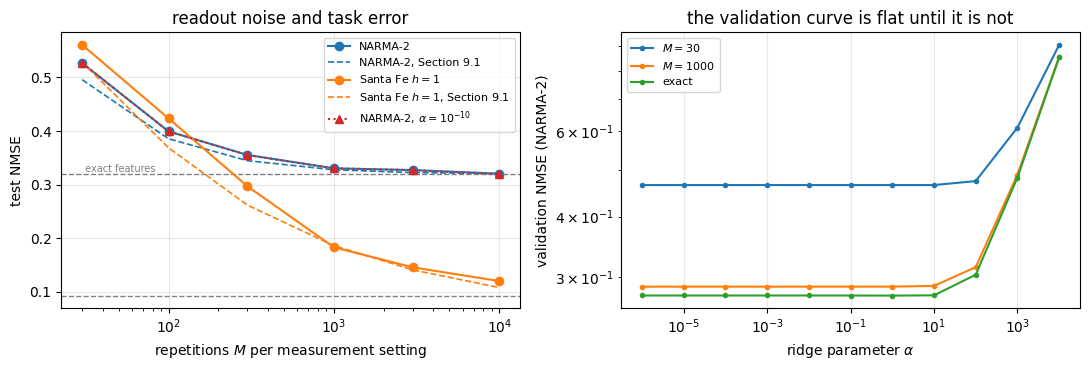

In [20]:
# ==============================================================================
# EXPERIMENT: task error versus the number of measurement repetitions
# ==============================================================================
M_SWEEP = (30, 100, 300, 1000, 3000, 10000)
rng_shot = np.random.default_rng(99)


def add_shot_noise(F, M, rng):
    """Replace each exact feature f by an estimate from M repetitions:  (2 Binomial(M,(1+f)/2) - M)/M."""
    p = np.clip(0.5 * (1.0 + F), 0.0, 1.0)
    return 2.0 * rng.binomial(M, p) / M - 1.0


def predicted_shot_nmse(F, y, M, washout=WASHOUT):
    """Errors-in-variables prediction of the test NMSE with features measured M times (Section 9.1).

    MATH  train on EXACT standardised features with the penalty D = n_tr diag(<1 - x_j^2>/(M s_j^2)),
          then add Eq. (16), sum_j w_j^2 (1 - x_kj^2)/(M s_j^2), averaged over the test block.
    Returns (predicted NMSE, ||w||^2 / var(y), median_j D_jj).
    """
    tr, va, te = split_indices(len(y), washout)
    mu, sd = F[tr].mean(0), F[tr].std(0)
    Xs = (F - mu) / sd
    v = (1.0 - F ** 2) / (M * sd ** 2)                          # error variances in standardised units
    D = v[tr].sum(0)
    G, b = normal_equations(Xs[tr], y[tr])
    w = np.linalg.solve(G + np.diag(np.append(D, 0.0)), b)
    mse = np.mean((ridge_predict(Xs[te], w) - y[te]) ** 2) + np.mean(v[te] @ w[:-1] ** 2)
    return mse / np.var(y[te]), np.sum(w[:-1] ** 2) / np.var(y[tr]), np.median(D)


tasks_shot = {"NARMA-2": (F_iid, lambda F: (F, targets["NARMA-2"])),
              "Santa Fe $h=1$": (F_sf1, lambda F: (F[:-1], u_sf[1:]))}
shot_curves = {t: [] for t in tasks_shot}
pred_curves = {t: [] for t in tasks_shot}
unreg_curve, val_curves, alpha_sel = [], {}, {}
for M in M_SWEEP + (None,):
    meas, pred, nn_raw, a_sel = {t: [] for t in tasks_shot}, {t: [] for t in tasks_shot}, [], []
    for i in range(N_RES):
        for t, (F_all, prep) in tasks_shot.items():
            F_ex, y_t = prep(F_all[i])
            F_n = F_ex if M is None else add_shot_noise(F_ex, M, rng_shot)
            e, _, a, _, _, curve = evaluate(F_n, y_t, return_curve=True)
            meas[t].append(e)
            if M is not None:
                pred[t].append(predicted_shot_nmse(F_ex, y_t, M))
            if t == "NARMA-2":
                a_sel.append(a)
                # the SAME fit with the regularisation switched off, to see what alpha is worth
                nn_raw.append(evaluate(F_n, y_t, alphas=[1e-10])[0])
                if i == 0 and M in (M_SWEEP[0], M_SWEEP[3], None):
                    val_curves[M] = curve
    for t in tasks_shot:
        shot_curves[t].append(np.median(meas[t]))
        if M is not None:
            pred_curves[t].append(np.median(np.array(pred[t])[:, 0]))
    unreg_curve.append(np.median(nn_raw))
    alpha_sel[M] = a_sel
    runs = "exact expectation values" if M is None else f"{3*M} runs per readout time"
    line = f"M = {str(M):>5s} ({runs:>26s}):  NARMA-2 {np.median(meas['NARMA-2']):.4f}"
    if M is not None:
        line += (f" (predicted {pred_curves['NARMA-2'][-1]:.4f}, unregularised {np.median(nn_raw):.4f}, "
                 f"median D_jj {np.median(np.array(pred['NARMA-2'])[:, 2]):6.1f})")
    line += f"   Santa Fe {np.median(meas['Santa Fe $h=1$']):.4f}"
    if M is not None:
        line += f" (predicted {pred_curves['Santa Fe $h=1$'][-1]:.4f})"
    print(line)
print("\nalpha chosen on the validation block (NARMA-2, six reservoirs):")
for M in M_SWEEP + (None,):
    print(f"  M = {str(M):>5s}: {[float(a) for a in alpha_sel[M]]}")
for t, (F_all, prep) in tasks_shot.items():
    wn = [predicted_shot_nmse(*prep(F_all[i]), 1e12)[1] for i in range(N_RES)]
    print(f"{t}: median ||w||^2 / var(y) of the exact-feature readout = {np.median(wn):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, v in shot_curves.items():
    line, = ax[0].semilogx(M_SWEEP, v[:-1], "o-", label=name)
    ax[0].semilogx(M_SWEEP, pred_curves[name], "--", color=line.get_color(), lw=1.2, label=f"{name}, Section 9.1")
    ax[0].axhline(v[-1], ls="--", lw=1, color="gray")
ax[0].semilogx(M_SWEEP, unreg_curve[:-1], "^:", color="tab:red", label=r"NARMA-2, $\alpha=10^{-10}$")
ax[0].set_xlabel("repetitions $M$ per measurement setting"); ax[0].set_ylabel("test NMSE")
ax[0].set_title("readout noise and task error"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].text(M_SWEEP[0], shot_curves["NARMA-2"][-1], " exact features", fontsize=7, va="bottom", color="gray")
for M, curve in val_curves.items():
    ax[1].loglog(ALPHAS, curve, "o-", ms=3, label=("exact" if M is None else f"$M={M}$"))
ax[1].set_xlabel(r"ridge parameter $\alpha$"); ax[1].set_ylabel("validation NMSE (NARMA-2)")
ax[1].set_title("the validation curve is flat until it is not")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Both tasks degrade smoothly, but at very different budgets. NARMA-2 is about $3\,\%$ above its exact-feature value
($0.320$) at $M=1000$ and indistinguishable from it at $M=10^4$; Santa Fe at $h=1$ is still a factor of $1.3$ above its
exact value ($0.093$) at $M=10^4$. The dashed lines are the prediction of Section 9.1, computed from the exact features
alone; they follow the measured medians to within $0.1$–$6\,\%$ for NARMA-2 and $2$–$13\,\%$ for Santa Fe, slightly
underestimating the damage at small $M$ where the first-order treatment of the noise is least accurate. The prediction also
names the cause of the difference between the tasks: the exact-feature readout for the laser has
$\lVert\tilde{\mathbf{w}}\rVert^2/\operatorname{var}(y)\approx10$, against $\approx1.1$ for NARMA-2. The laser readout
reaches its small error by large weights of opposite sign on correlated features, and Eq. (16) multiplies every such weight
by the shot noise. A small exact error achieved this way is precisely what the measurement budget has to pay for.

In units of laboratory time the horizontal axis is expensive. $M$ repetitions per measurement setting means $3M$ runs of
the sequence **for every readout time**, because the three settings are incompatible and a projective measurement destroys
the state: $M=10^3$ is $3000$ runs per time step, and with $1100$ usable time steps that is $3\cdot10^6$ runs of an
experiment whose length itself grows with the step index. This is the quadratic cost of the restarting protocol, and the
reason for the rewinding protocol (replay only the last few memory times of the input, about ten to twenty steps at
$\tau=0.5$ according to Section 5) and for the weak-measurement online protocol of Mujal *et al.*

The second panel and the printed $\alpha$ values test the first prediction of Section 9.1. The validation curve is flat
from $\alpha=10^{-6}$ to $\alpha\approx10$ at every noise level, the $\alpha$ chosen on the validation block jumps between
the ends of that flat region without any trend in $M$, and the test error with the regularisation switched off
($\alpha=10^{-10}$, the red triangles) is indistinguishable from the tuned one. The implicit penalty explains the noisy
cases: its median strength $D_{jj}$ is $394$ at $M=30$ and $12$ at $M=1000$, far above any $\alpha$ in the flat region.
For exact features there is no implicit penalty, and the flat curve has the plainer reason that the least-squares problem is
well conditioned ($660$ training points, $21$ standardised features, smallest-to-largest singular-value ratio $0.068$).
Explicit regularisation earns its keep in the opposite regime — the deliberately collinear design matrix of Section 2.4,
or a feature count approaching the number of training samples, which is where $V=4$ multiplexing and larger reservoirs
would take us.

## 10. Decoherence during the evolution

A laboratory reservoir is not unitary between inputs. Add a Lindblad channel acting on every qubit during the evolution —
dephasing ($L=Z$, coherences decay as $e^{-2\gamma t}$) or amplitude damping ($L=\sigma^+=\vert0\rangle\langle1\vert$, excited population decays as
$e^{-\gamma t}$) with rate $\gamma$ — implemented as one Kraus pair per Trotter sub-step, as in
[notebook 16](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb). We use the *exact* single-qubit channel of
each sub-step, $p=\tfrac12(1-e^{-2\gamma\delta t})$ for dephasing and $1-e^{-\gamma\delta t}$ for damping, rather than the
first-order pair of `kraus_from_jump`: for $\gamma\delta t=0.375$ (the case $\gamma=3$) the first-order pair would turn
a coherence factor $e^{-0.75}=0.47$ into $1-0.75=0.25$, and for $\gamma\delta t>1$ it is not even trace preserving. The
dephasing rate is swept over two decades, and the value used for each task is chosen on the validation block. The question is not
only how much performance is lost: dissipation is also a second source of forgetting, and a machine whose coherent
dynamics scatters the memory of an input over many oscillating features may prefer a damped one.

dephasing gamma =  0.00:  MC = 3.817, C(1) = 0.905, C(3) = 0.644, NARMA-2 0.3198 (val 0.2664), Santa Fe 0.0931 (val 0.0259)


dephasing gamma =  0.10:  MC = 3.795, C(1) = 0.940, C(3) = 0.717, NARMA-2 0.2238 (val 0.1879), Santa Fe 0.0802 (val 0.0163)


dephasing gamma =  0.30:  MC = 3.759, C(1) = 0.970, C(3) = 0.795, NARMA-2 0.1783 (val 0.1429), Santa Fe 0.0700 (val 0.0134)


dephasing gamma =  1.00:  MC = 3.770, C(1) = 0.984, C(3) = 0.858, NARMA-2 0.0812 (val 0.0666), Santa Fe 0.0672 (val 0.0101)


dephasing gamma =  3.00:  MC = 3.189, C(1) = 0.985, C(3) = 0.459, NARMA-2 0.0603 (val 0.0539), Santa Fe 0.0785 (val 0.0190)


dephasing gamma = 10.00:  MC = 3.160, C(1) = 0.963, C(3) = 0.289, NARMA-2 0.1919 (val 0.1870), Santa Fe 0.1192 (val 0.0204)
NARMA-2: gamma chosen on the validation block = 3.0, test NMSE 0.0603 [0.054, 0.076]
Santa Fe h=1: gamma chosen on the validation block = 1.0, test NMSE 0.0672 [0.057, 0.077]


amplitude damping gamma = 0.30:  MC = 3.900, C(1) = 0.954, NARMA-2 0.1990, Santa Fe 0.0710


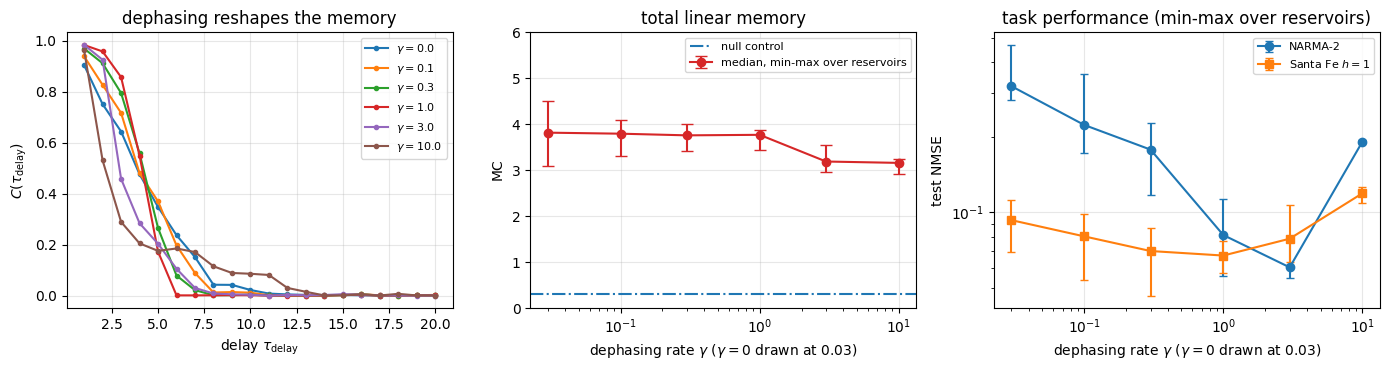


purity of the driven state: gamma = 0: 0.4335, gamma = 1: 0.0713 (maximally mixed would be 0.0625)


In [21]:
# ==============================================================================
# EXPERIMENT: dephasing and amplitude damping during the evolution
# ==============================================================================
def dephasing_channel(gamma_dt):
    """Exact solution of drho/dt = gamma (Z rho Z - rho) over gamma_dt: coherences x exp(-2 gamma dt)."""
    return kraus_dephasing(0.5 * (1.0 - jnp.exp(-2.0 * gamma_dt)))


def damping_channel(gamma_dt):
    """Exact solution of drho/dt = gamma D[sigma^+](rho) over gamma_dt: excited population x exp(-gamma dt)."""
    return kraus_amplitude_damping(1.0 - jnp.exp(-gamma_dt))


GAMMAS = (0.0, 0.1, 0.3, 1.0, 3.0, 10.0)
deco, deco_val = {}, {}
for gamma in GAMMAS:
    jump = None if gamma == 0.0 else dephasing_channel
    F_g, t_g = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, jump=jump, gamma=gamma)
    F_gs, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, jump=jump, gamma=gamma)
    caps_g = np.array([memory_capacity(F_g[i], u_iid) for i in range(N_RES)])
    nn = np.array([score_val(F_g[i], targets["NARMA-2"]) for i in range(N_RES)])        # (test, validation)
    sf = np.array([score_val(F_gs[i][:-1], u_sf[1:]) for i in range(N_RES)])
    deco[gamma] = (caps_g, nn[:, 0], sf[:, 0])
    deco_val[gamma] = (nn[:, 1], sf[:, 1])
    print(f"dephasing gamma = {gamma:5.2f}:  MC = {np.median(caps_g.sum(1)):.3f}, "
          f"C(1) = {np.median(caps_g[:, 0]):.3f}, C(3) = {np.median(caps_g[:, 2]):.3f}, "
          f"NARMA-2 {np.median(nn[:, 0]):.4f} (val {np.median(nn[:, 1]):.4f}), "
          f"Santa Fe {np.median(sf[:, 0]):.4f} (val {np.median(sf[:, 1]):.4f})")
for k, name in enumerate(("NARMA-2", "Santa Fe h=1")):
    g_best = min(GAMMAS, key=lambda g: np.median(deco_val[g][k]))
    v = deco[g_best][1 + k]
    print(f"{name}: gamma chosen on the validation block = {g_best}, test NMSE {np.median(v):.4f} [{v.min():.3f}, {v.max():.3f}]")

F_ad, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, jump=damping_channel, gamma=0.3)
F_ads, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, jump=damping_channel, gamma=0.3)
caps_ad = np.array([memory_capacity(F_ad[i], u_iid) for i in range(N_RES)])
nn_ad = np.array([evaluate(F_ad[i], targets["NARMA-2"])[0] for i in range(N_RES)])
sf_ad = np.array([horizon_scores(F_ads[i], u_sf, 1)[0] for i in range(N_RES)])
print(f"amplitude damping gamma = 0.30:  MC = {np.median(caps_ad.sum(1)):.3f}, C(1) = {np.median(caps_ad[:, 0]):.3f}, "
      f"NARMA-2 {np.median(nn_ad):.4f}, Santa Fe {np.median(sf_ad):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for gamma in GAMMAS:
    ax[0].plot(TAUS_MC[:20], np.median(deco[gamma][0], axis=0)[:20], "o-", ms=3, label=rf"$\gamma={gamma}$")
ax[0].set_xlabel(r"delay $\tau_{\rm delay}$"); ax[0].set_ylabel(r"$C(\tau_{\rm delay})$")
ax[0].set_title("dephasing reshapes the memory"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
g_plot = [max(g, 0.03) for g in GAMMAS]                     # gamma = 0 drawn at 0.03 on the log axis
mc_g = [deco[g][0].sum(1) for g in GAMMAS]
ax[1].errorbar(g_plot, [np.median(m) for m in mc_g],
               yerr=[[np.median(m) - m.min() for m in mc_g], [m.max() - np.median(m) for m in mc_g]],
               fmt="o-", capsize=4, color="tab:red", label="median, min-max over reservoirs")
ax[1].axhline(MC_null.mean(), ls="-.", color="tab:blue", label="null control")
ax[1].set_ylim(0, 6); ax[1].set_xscale("log")
ax[1].set_xlabel(r"dephasing rate $\gamma$ ($\gamma=0$ drawn at $0.03$)"); ax[1].set_ylabel(r"$\mathrm{MC}$")
ax[1].set_title("total linear memory"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
for k, (name, mk) in enumerate((("NARMA-2", "o-"), ("Santa Fe $h=1$", "s-"))):
    vals = [deco[g][1 + k] for g in GAMMAS]
    ax[2].errorbar(g_plot, [np.median(v) for v in vals],
                   yerr=[[np.median(v) - v.min() for v in vals], [v.max() - np.median(v) for v in vals]],
                   fmt=mk, capsize=3, label=name)
ax[2].set_xscale("log"); ax[2].set_yscale("log")
ax[2].set_xlabel(r"dephasing rate $\gamma$ ($\gamma=0$ drawn at $0.03$)"); ax[2].set_ylabel("test NMSE")
ax[2].set_title("task performance (min-max over reservoirs)"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

rho_end_coh = driver_ml(Js_demo, hs_demo, input_windows(u_iid[:200], L_IN), to_dm(zero_state(N_QUBITS)))[0]
drv_deph = make_dm_driver(L_IN, N_RAILS, TAU, DT, jump=dephasing_channel, gamma=1.0)
rho_end_deph = drv_deph(Js_demo, hs_demo, input_windows(u_iid[:200], L_IN), to_dm(zero_state(N_QUBITS)))[0]
print(f"\npurity of the driven state: gamma = 0: {float(purity(dm_matrix(rho_end_coh))):.4f}, "
      f"gamma = 1: {float(purity(dm_matrix(rho_end_deph))):.4f} "
      f"(maximally mixed would be {1/2**N_QUBITS:.4f})")

Moderate dephasing improves both tasks, and the mechanism is visible in the first panel.

* **Up to $\gamma=1$ the total linear memory barely moves**: $\mathrm{MC}=3.82,\,3.80,\,3.76,\,3.77$ for
  $\gamma=0,0.1,0.3,1$, differences far below the uncertainty $\pm0.45$ of one MC value. Stronger dephasing does remove
  memory: $3.19$ at $\gamma=3$ and $3.16$ at $\gamma=10$.
* **The profile changes completely.** Dephasing first *sharpens* the short-time memory and truncates the long tail:
  $C(1)$ rises from $0.905$ to $0.984$ and $C(3)$ from $0.644$ to $0.858$ between $\gamma=0$ and $\gamma=1$, while the
  delays beyond about six steps are wiped out. Coherent evolution spreads the trace of an input over many oscillating
  features, where a linear readout recovers it only partially; damping leaves a cleaner, monotonically decaying memory
  kernel. At $\gamma=3$ the memory shrinks to the last two inputs ($C(3)=0.46$); at $\gamma=10$ only the
  last input is recalled well ($C(3)=0.29$), followed by a weak tail of $C\approx0.1$ out to about ten delays.
* **The task errors track the short-delay capacities.** NARMA-2 improves from $0.320$ to $0.081$ at $\gamma=1$ and $0.060$ at
  $\gamma=3$, the value chosen on the validation block; one-step laser prediction improves from $0.093$ to $0.067$ at
  $\gamma=1$, again the validated choice, and degrades for stronger dephasing. NARMA-2 needs an accurate memory of the
  last few steps and little beyond, which is what dephasing delivers.
* **Against the baselines of Sections 7 and 8**, the validated dissipative reservoir beats the default-scaled echo-state
  network and the linear autoregression on NARMA-2 ($0.060$ against $0.147$ and $0.152$) but not the echo-state network
  tuned on the same validation data ($0.026$) or the quadratic autoregression ($0.005$); on the laser it ($0.067$) stays
  behind the tuned $21$-unit network ($0.042$). Decoherence narrows the gap without closing it.
* Amplitude damping at $\gamma=0.3$ behaves like dephasing at the same rate ($\mathrm{MC}=3.90$, $C(1)=0.954$, NARMA-2
  $0.199$, laser $0.071$, against $0.178$ and $0.070$ for dephasing), so the effect is not specific to one channel.

The purity of the driven state falls from $0.43$ to $0.071$ at $\gamma=1$, against $1/2^N=0.0625$ for the maximally mixed
state: the reservoir is almost completely mixed and still computes better than the coherent one. Its computation does
not rely on the purity of its state.

> **Physics insight.** For a reservoir, decoherence is not only a loss. The task of a reservoir is to forget in a
> *useful* way, and a dissipative bath is a perfectly good forgetting mechanism — at moderate rates a better-shaped one
> than unitary scrambling followed by an erasure, at large rates a destructive one. Dissipative quantum reservoirs are
> analysed by Chen and Nurdin; how the performance depends on the dynamical regime of the reservoir is the subject of
> Martínez-Peña *et al.*, who find the thermalising (ergodic) phase of a disordered spin network well suited to reservoir
> computing, with the best performance near its transition to many-body localisation.

### 10.1 The comparison at equal feature count

The table collects the test NMSE printed in Sections 7, 8 and 10 (medians over six random reservoirs or six ESN seeds;
$p=21$ features in every column).

| task | QRC, $\tau=0.5$ | QRC, $\tau$ chosen on validation | QRC with dephasing, $\gamma$ chosen on validation | ESN, default scalings | ESN, tuned | AR | AR$^2$ |
|---|---|---|---|---|---|---|---|
| NARMA-2 | $0.320$ | $0.211$ ($\tau=1$) | $0.060$ ($\gamma=3$) | $0.147$ | $0.026$ | $0.152$ | $0.005$ |
| NARMA-5 | $0.618$ | $0.489$ ($\tau=2$) | — | $0.274$ | $0.126$ | $0.132$ | $0.135$ |
| NARMA-10 | $0.784$ | $0.747$ ($\tau=0.25$) | — | $0.690$ | $0.283$ | $0.187$ | $0.381$ |
| Santa Fe, $h=1$ | $0.093$ | — | $0.067$ ($\gamma=1$) | $0.097$ | $0.042$ | $0.260$ | $0.106$ |

The conditions are the same for every column: the same input sequence, the same contiguous washout, training,
validation and test blocks, the same ridge readout with $\alpha$ chosen on the validation block, and $21$ features
($3N+3B$ Pauli expectation values for $N=4$, $21$ network units, $21$ input lags, or $11$ lags and $10$ squares). Every
remaining hyper-parameter is chosen by the median validation NMSE before the test block is evaluated: the spectral radius
and input scale of the network from a $3\times4$ grid, the evolution time of the reservoir from five values, its dephasing
rate from six (at $\tau=0.5$). Dashes mark combinations that were not run.

Read off the table, the four-qubit reservoir

* has a larger error than the tuned echo-state network on all four tasks, by factors of $2.3$ (NARMA-2), $3.9$
  (NARMA-5), $2.6$ (NARMA-10) and $1.6$ (laser), and in every row the range of its best validated configuration over
  reservoirs does not overlap the range of the network over seeds;
* is also behind the linear autoregression on NARMA-5 and NARMA-10;
* beats the two lag models on the laser series ($0.093$ against $0.26$ and $0.11$), and with validated dephasing it beats
  the default-scaled network and the linear autoregression on NARMA-2.

Two results lie outside the equal-feature comparison. Multiplexing to $84$ features lowers the laser error to $0.024$,
below the tuned $21$-unit network; a network with $84$ units was not run, and one with $200$ units reaches $0.012$. And
the reservoir knobs that were not tuned here (field-to-coupling ratio, encoding, size, readout times) leave room for
improvement; Exercise 4 maps one of them.

The literature discusses two routes to a benefit, and this notebook tests neither. First, the number of observables
that can serve as features grows with the Hilbert-space dimension, and the review of Mujal *et al.* (Ref. 13) collects
work that quantifies how much of it a readout can use; Fujii and Nakajima (Ref. 8) found spin reservoirs of $5$–$7$
qubits, each qubit read out at $V$ instants per input step, comparable to echo-state networks of $100$–$500$ nodes; that
comparison counts qubits against network nodes, while the table above counts readout features. Second, the same review points
to tasks whose input is itself a quantum state, such as entanglement detection or state tomography, which a classical
reservoir can only receive after measuring it.

## 11. Cost

The density-tensor driver keeps $4^N$ complex numbers and applies $O(V n_{\rm sub} G)$ gates per input step, each costing
$O(2^k4^N)$, plus $O((N+B)4^N)$ for the readout: **exponential in the number of qubits, linear in the length of the
series**. The trajectory driver keeps $2^N$ numbers per trajectory, $M2^N$ for a batch of $M$, and so needs less memory
than the density tensor only if $M<2^N$, and its work per step, $M\cdot2^N$ against $4^N$, buys only the statistical
accuracy of $M$ samples. For small reservoirs the density tensor wins outright, which is why every experiment above used it.
The measurement below separates compilation (once per shape and per parameter set) from execution.

In [22]:
# ==============================================================================
# PERFORMANCE: cost per input step versus the number of qubits
# ==============================================================================
u_bench = np.random.default_rng(0).uniform(0.0, 1.0, 200)
print(f"{'N':>2s} {'p':>4s} {'compile (s)':>12s} {'run (s)':>9s} {'ms / input step':>16s} "
      f"{'ratio to N-1':>13s} {'rho memory':>12s}")
prev_t, t_dm_same_N = None, 0.0
for R_b in (2, 3, 4, 5, 6):
    Js_b, hs_b = reservoir_params(jax.random.PRNGKey(SEED_RES), 1, R_b, W=W_DIS)
    drv_b = make_dm_driver(1, R_b, TAU, DT)
    W_b, rho0_b = input_windows(u_bench, 1), to_dm(zero_state(R_b))
    t0 = time.time(); drv_b(Js_b, hs_b, W_b, rho0_b)[0].block_until_ready(); t_comp = time.time() - t0
    t0 = time.time(); drv_b(Js_b, hs_b, W_b, rho0_b)[0].block_until_ready(); t_run = time.time() - t0
    mem = 16 * 4 ** R_b
    print(f"{R_b:2d} {3*R_b + 3*(R_b-1):4d} {t_comp - t_run:12.2f} {t_run:9.3f} {1e3*t_run/len(u_bench):16.2f} "
          f"{'--' if prev_t is None else f'{t_run/prev_t:12.2f}'} "
          f"{mem/1000:9.1f} kB")
    prev_t = t_run
    if R_b == N_QUBITS:
        t_dm_same_N = t_run

M_bench = 256
keys_b = jax.random.split(jax.random.PRNGKey(0), M_bench)
t0 = time.time(); vmcwf(Js_demo, hs_demo, input_windows(u_bench, 1), zero_state(N_QUBITS), keys_b)[1].block_until_ready()
t_comp_mc = time.time() - t0
t0 = time.time(); vmcwf(Js_demo, hs_demo, input_windows(u_bench, 1), zero_state(N_QUBITS), keys_b)[1].block_until_ready()
t_run_mc = time.time() - t0
print(f"\nN = {N_QUBITS}: {M_bench} trajectories over {len(u_bench)} steps: compile {t_comp_mc - t_run_mc:.2f} s, "
      f"run {t_run_mc:.3f} s  ->  {1e3*t_run_mc/len(u_bench):.2f} ms per input step for the whole batch, "
      f"against {1e3*t_dm_same_N/len(u_bench):.2f} ms for the density tensor of the same N in the table above")

 N    p  compile (s)   run (s)  ms / input step  ratio to N-1   rho memory


 2    9         0.17     0.006             0.03 --       0.3 kB


 3   15         0.24     0.016             0.08         2.66       1.0 kB


 4   21         0.33     0.038             0.19         2.40       4.1 kB


 5   27         0.45     0.120             0.60         3.15      16.4 kB


 6   33         0.87     0.661             3.31         5.50      65.5 kB



N = 4: 256 trajectories over 200 steps: compile 0.58 s, run 0.308 s  ->  1.54 ms per input step for the whole batch, against 0.19 ms for the density tensor of the same N in the table above


The cost per input step grows by roughly the predicted factor of four per added qubit at the upper end of the table,
while the ratios at $N\le4$ are smaller and erratic: there the tensors have a few hundred entries and the time is set by
kernel dispatch rather than by arithmetic. (Absolute timings on a shared machine move by tens of per cent between runs, and by
factors of several when other jobs compete for the processor; the $4^N$ scaling at large $N$ is the robust part, the
small-$N$ ratios are not.) Extrapolating that factor, $N=8$ would need a $1.0$ MB density tensor and of order $0.1$ s per input
step — still workable for a thousand-step series — and $N=10$ a $17$ MB tensor and seconds per step. That is the practical
wall of the method, and it is a wall in $N$ alone: the length of the time series enters linearly.

The trajectory driver is several times slower here for $256$ trajectories than the exact density tensor at $N=4$, which
is the expected verdict at small $N$: $M\cdot2^N$ beats $4^N$ only when $M<2^N$, and a useful $M$ is in the hundreds.
Trajectories become the only option when $4^N$ no longer fits in memory — and they are what an experiment does anyway.

> **JAX practice.** Compilation takes $0.2$–$2$ s per configuration (printed above and in Sections 6 and 8, where
> `drive_ensemble` compiles ahead of time with `lower(...).compile()` and times the execution separately) and is paid once
> per *shape and static argument set*. Because `Js` and `hs` are traced arrays, all six random reservoirs share one
> compiled program through `jax.vmap`, and a sweep over disorder costs one compilation instead of six. Changing $\tau$, $V$
> or $\delta t$ changes the gate count and does force a recompilation — which is why the parameter sweeps above are
> organised as an outer Python loop over geometry and an inner `vmap` over reservoirs, and not the other way round.

## 12. Summary

**Key takeaways**

* Reservoir computing turns sequence learning into linear regression by refusing to train the dynamics. Everything then
  depends on two properties of the fixed dynamical system: it must forget its initial condition (echo state) and it must
  mix past inputs nonlinearly (separation). In a driven many-body quantum system the erasure of the input qubits — a
  replacement channel, completely positive and trace preserving — supplies the forgetting; unitary evolution alone never
  forgets.
* The quantum feature map is exactly multilinear in the vectors $(1,\cos\pi u_j,\sin\pi u_j)$ of the past inputs. The
  single-input nonlinearity is the encoding; the products across different times come from the input entering the state
  multiplicatively at every reset; the Hamiltonian, linear and input-independent, sets the coefficients.
* Two independent implementations of the same protocol — a density tensor with a Kraus reset and pure-state trajectories
  with measurement and reset — agree within the $1/\sqrt M$ statistical error (rms pull $1.0$), and the same comparison
  rejects a wrong erasure by a pull of almost $90$ and resolves the Trotter error of the production time step.
* The measured linear memory capacity, $3.8\pm0.45$ for one reservoir of four qubits, stays far below the number of
  readout features. The bound of Jaeger and of Dambre *et al.* counts *linearly independent* state variables, and the one-
  and two-body Pauli features of a small lattice are strongly redundant. At $220$ test points the estimate carries an
  upward bias of $0.3$ (null control) and a downward bias of similar size from the finite training block; a slowly
  forgetting reservoir hides much of its capacity in a faint tail that a sum over twenty delays misses.
* At an *equal number of readout features*, with every baseline's hyper-parameters chosen on the validation block, the
  four-qubit reservoir has a larger test error than the tuned classical echo-state network on all four tasks, also after
  its own evolution time or dephasing rate is chosen on the validation block (NARMA-2: $0.060$ against $0.026$; NARMA-5:
  $0.49$ against $0.13$; NARMA-10: $0.75$ against $0.28$; laser: $0.067$ against $0.042$; table of Section 10.1). It
  beats the lag models on the laser series only. Against untuned baselines the laser comparison looked like a draw; the
  draw disappeared when the baseline was tuned.
* Finite measurement statistics act on the readout in two ways that Eq. (16) and the implicit ridge penalty $D$ describe
  quantitatively: the shot noise regularises the fit by itself, and it multiplies the squared readout weights, so a task
  solved by large, cancelling weights (the laser) suffers far more than one solved by small weights (NARMA-2). What scales
  worst is the number of experiments, because a projective readout destroys the state and the input sequence has to be
  replayed for every readout time unless a rewinding or weak-measurement protocol is used.
* Moderate dephasing during the evolution leaves the total linear memory unchanged within errors but moves it from a long
  weak tail into the first few delays ($C(1)$ from $0.91$ to $0.98$, $C(3)$ from $0.64$ to $0.86$ at $\gamma=1$); every
  task that needs accurate short memory improves (NARMA-2 from $0.32$ to $0.06$ at the validated rate), even though the
  state is then almost maximally mixed. Strong dephasing destroys memory.

## 13. Exercises

1. (&#9733;) **Encoding.** Replace $R_y(\pi u)$ by the Fujii–Nakajima encoding
   $\sqrt{1-u}\,\vert0\rangle+\sqrt{u}\,\vert1\rangle$, for which $\langle Z\rangle$ is linear in $u$. Re-measure
   $C(\tau)$ and the NARMA-2 error. Does the linear-in-$u$ encoding help the linear task and hurt the nonlinear one?
2. (&#9733;) **Washout.** Set `WASHOUT = 0` and re-run the memory-capacity cell, at $\tau=0.125$ and at $\tau=2$. Compare
   with the echo-state decay rates of Section 5 and with the uncertainty of one MC value from Section 6.1. Why can the
   washout matter so little even where Section 5 shows that the initial state is far from forgotten?
3. (&#9733;&#9733;) **Readout set.** Drop the two-body correlators and keep only the $3N$ single-qubit features
   (`readout_ops` needs one line changed). How much capacity is lost, and how does the loss compare with the drop in the
   number of features? Then add the $\langle X_iY_j\rangle$-type mixed correlators and check whether the extra features
   are linearly independent of the ones already there (look at the singular values).
4. (&#9733;&#9733;) **The knob.** Map the plane $(\tau, h/J)$: for a grid of evolution times and field-to-coupling ratios,
   measure $\mathrm{MC}$ and the NARMA-2 error over several reservoirs. Where is the useful region, and does the best
   $\tau$ for memory coincide with the best $\tau$ for the nonlinear task?
5. (&#9733;&#9733;) **Extend the code: virtual nodes with unequal spacing.** The multiplexing in `make_dm_driver` reads
   out at equal intervals $\tau/V$. Implement logarithmic spacing and compare the capacity at the same $V$.
6. (&#9733;&#9733;&#9733;) **Free-running prediction.** Instead of predicting $u_{k+h}$ with a separate readout per
   horizon, feed the one-step prediction back as the next input and let the machine run autonomously. Measure how many
   steps the free-running series stays close to the laser data, and compare with the direct multi-step results of
   Section 8.
7. (&#9733;&#9733;&#9733;) **Physics: where does the memory live?** The driven state is mixed, so the entanglement
   entropy of a bipartition is not a measure of correlations. Track instead the quantum mutual information
   $I(\mathrm{in}:\mathrm{mem})=S(\rho_{\rm in})+S(\rho_{\rm mem})-S(\rho)$ between the input rail and the memory rails
   just before each erasure, and the purity of the reservoir state, for $\tau=0.125$, $0.5$ and $2$. Relate what you find
   to the forgetting rates of Section 5 and to the capacity profiles of Section 6.
8. (&#9733;&#9733;&#9733;) **Trajectories as the readout.** Train the readout on features averaged over $M$ *trajectories*
   rather than on exact expectation values plus binomial noise, and compare the two noise models at equal $M$. Which one
   is optimistic, and why?

## 14. References

1. H. Jaeger, *The "echo state" approach to analysing and training recurrent neural networks*, GMD Report 148, German
   National Research Center for Information Technology (2001); reissued with an erratum note (2010) correcting
   Definition 3 and Proposition 1.
2. H. Jaeger, *Short term memory in echo state networks*, GMD Report 152, GMD – Forschungszentrum Informationstechnik
   GmbH (2002). Proposition 2: for i.i.d. input and linear output units the memory capacity
   $\mathrm{MC}=\sum_{k\ge1}\mathrm{MC}_k$ of an $N$-unit network obeys $\mathrm{MC}\le N$.
3. W. Maass, T. Natschläger and H. Markram, *Real-time computing without stable states: a new framework for neural
   computation based on perturbations*, Neural Computation **14**, 2531 (2002).
4. H. Jaeger and H. Haas, *Harnessing nonlinearity: predicting chaotic systems and saving energy in wireless
   communication*, Science **304**, 78 (2004). Echo-state networks applied to chaotic time-series prediction.
5. M. Lukoševičius and H. Jaeger, *Reservoir computing approaches to recurrent neural network training*, Computer
   Science Review **3**, 127 (2009).
6. I. B. Yildiz, H. Jaeger and S. J. Kiebel, *Re-visiting the echo state property*, Neural Networks **35**, 1 (2012).
7. J. Dambre, D. Verstraeten, B. Schrauwen and S. Massar, *Information processing capacity of dynamical systems*,
   Scientific Reports **2**, 514 (2012).
8. K. Fujii and K. Nakajima, *Harnessing disordered-ensemble quantum dynamics for machine learning*, Physical Review
   Applied **8**, 024030 (2017).
9. K. Nakajima, K. Fujii, M. Negoro, K. Mitarai and M. Kitagawa, *Boosting computational power through spatial
   multiplexing in quantum reservoir computing*, Physical Review Applied **11**, 034021 (2019). Several disjoint
   quantum reservoirs read out by one linear readout.
10. J. Chen and H. I. Nurdin, *Learning nonlinear input-output maps with dissipative quantum systems*, Quantum
    Information Processing **18**, 198 (2019).
11. J. Chen, H. I. Nurdin and N. Yamamoto, *Temporal information processing on noisy quantum computers*, Physical Review
    Applied **14**, 024065 (2020). Quantum reservoirs on superconducting quantum computers; the quadratic cost of
    replaying the input and its reduction through fading memory.
12. R. Martínez-Peña, G. L. Giorgi, J. Nokkala, M. C. Soriano and R. Zambrini, *Dynamical phase transitions in quantum
    reservoir computing*, Physical Review Letters **127**, 100502 (2021).
13. P. Mujal, R. Martínez-Peña, J. Nokkala, J. García-Beni, G. L. Giorgi, M. C. Soriano and R. Zambrini,
    *Opportunities in quantum reservoir computing and extreme learning machines*, Advanced Quantum Technologies **4**,
    2100027 (2021). A review of quantum reservoir computing.
14. P. Mujal, R. Martínez-Peña, G. L. Giorgi, M. C. Soriano and R. Zambrini, *Time-series quantum reservoir computing
    with weak and projective measurements*, npj Quantum Information **9**, 16 (2023).
15. A. S. Weigend and N. A. Gershenfeld (editors), *Time Series Prediction: Forecasting the Future and Understanding the
    Past*, Santa Fe Institute Studies in the Sciences of Complexity, Proceedings Volume XV (Addison-Wesley, Reading,
    1994). Data set A was contributed by U. Hübner, from data collected primarily by N. B. Abraham and C. O. Weiss; see also
    U. Hübner, N. B. Abraham and C. O. Weiss, *Dimensions and entropies of chaotic intensity pulsations in a
    single-mode far-infrared NH3 laser*, Physical Review A **40**, 6354 (1989).
16. A. F. Atiya and A. G. Parlos, *New results on recurrent network training: unifying the algorithms and accelerating
    convergence*, IEEE Transactions on Neural Networks **11**, 697 (2000). Source of the second-order system of Eq. (6)
    and of the tenth-order system that the reservoir-computing literature calls NARMA-10; Fujii and Nakajima (Ref. 8,
    their Eq. (18)) use the NARMA-$n$ form of Eq. (7) with these coefficients for $n=5,10,15,20$. NARMA-10 is also a
    benchmark of A. Rodan and P. Tiňo, *Minimum complexity echo state network*, IEEE Transactions on Neural Networks
    **22**, 131 (2011).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/